# Ejercicio 05: Clasificación Multiclase con Red Neuronal (Wine Dataset)

Este cuaderno entrena 10 modelos diferentes de redes neuronales para clasificar vinos en 3 categorías usando el dataset Wine.

**Características del dataset:**
- Total: 178 registros
- 3 clases de vinos (1, 2, 3)
- 13 características químicas

**Modelos entrenados:**
1. **Modelo 1-3**: Modelos base con diferentes números de características
2. **Modelo 4-6**: Modelos con Dropout para regularización
3. **Modelo 7-10**: Modelos optimizados para métricas específicas (Accuracy, Recall, Precision, F1-Score)

**Nota sobre el rendimiento:** El dataset Wine está muy bien separado, por lo que es normal obtener alta precisión incluso con modelos simples.

c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


First 5 records:
    class  Alcohol  Malicacid   Ash  Alcalinity_of_ash  Magnesium  \
0      1    14.23       1.71  2.43               15.6        127   
1      1    13.20       1.78  2.14               11.2        100   
2      1    13.16       2.36  2.67               18.6        101   
3      1    14.37       1.95  2.50               16.8        113   
4      1    13.24       2.59  2.87               21.0        118   

   Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color_intensity   Hue  OD280/OD315_of_diluted_wines  Proline  
0             5.64  1.04                          3.92     1065  
1             

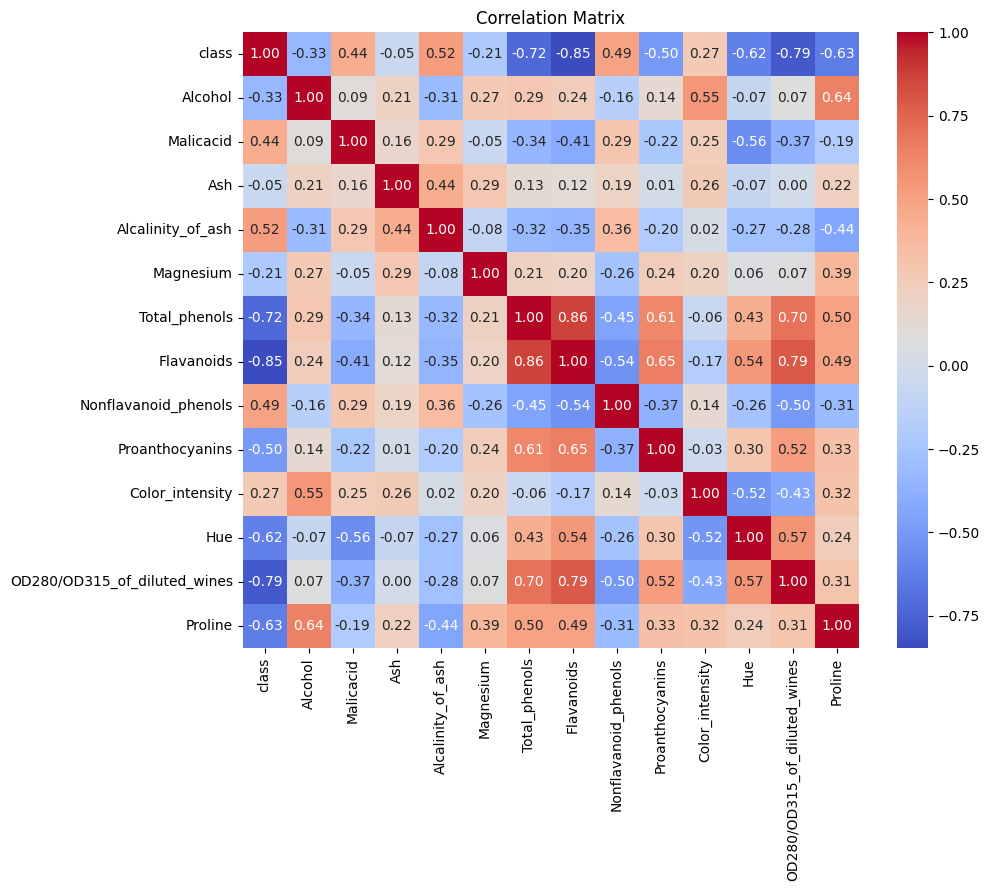


Plotting hist plots for numeric columns...


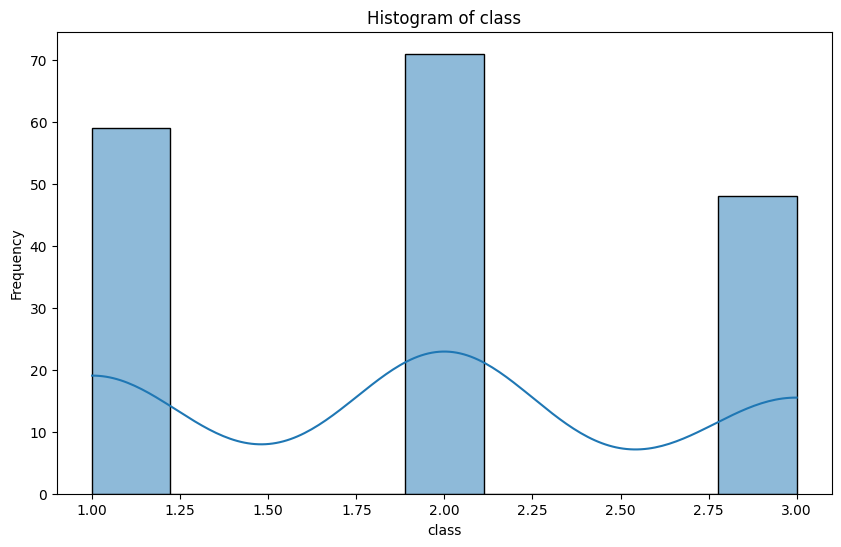

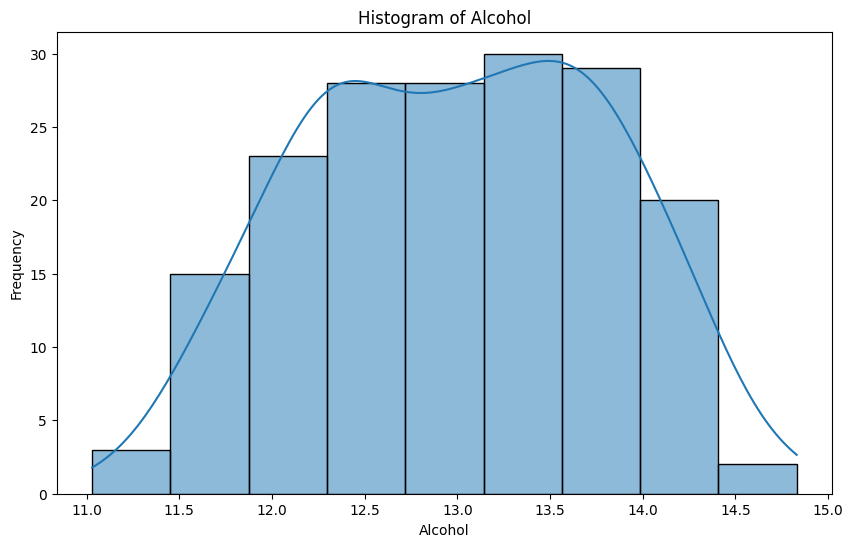

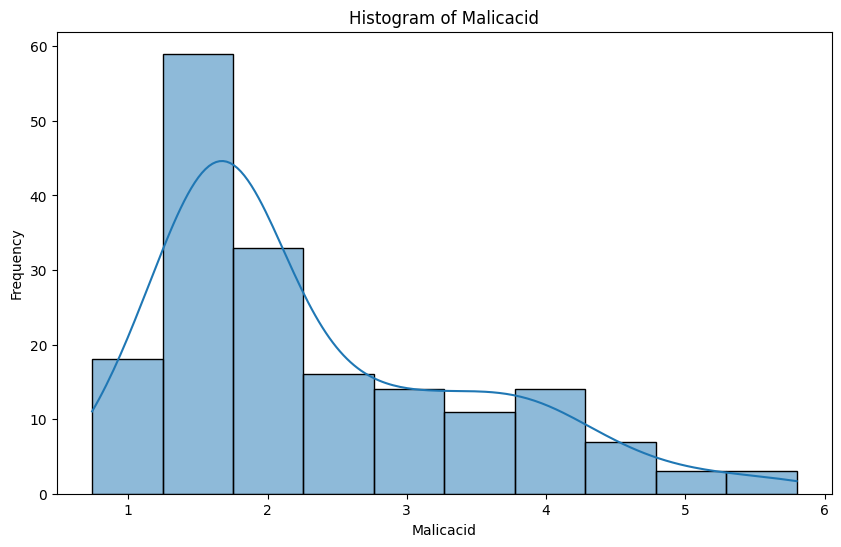

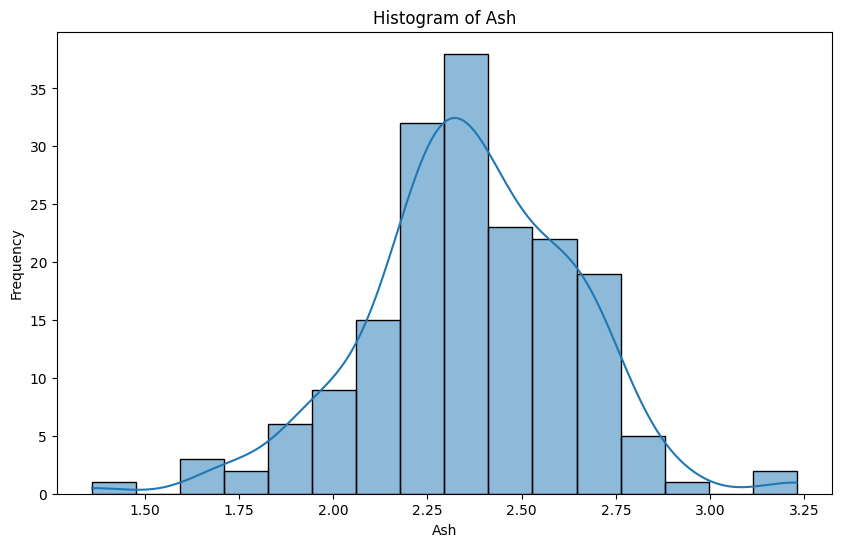

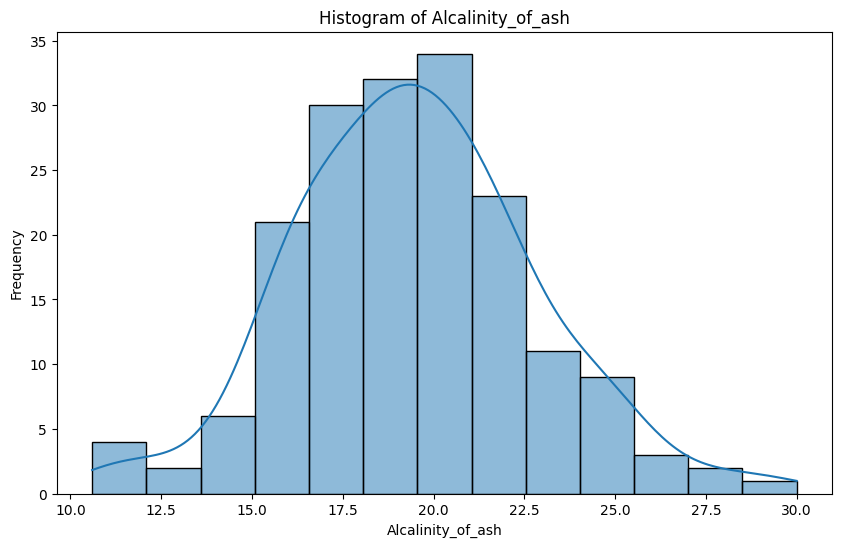

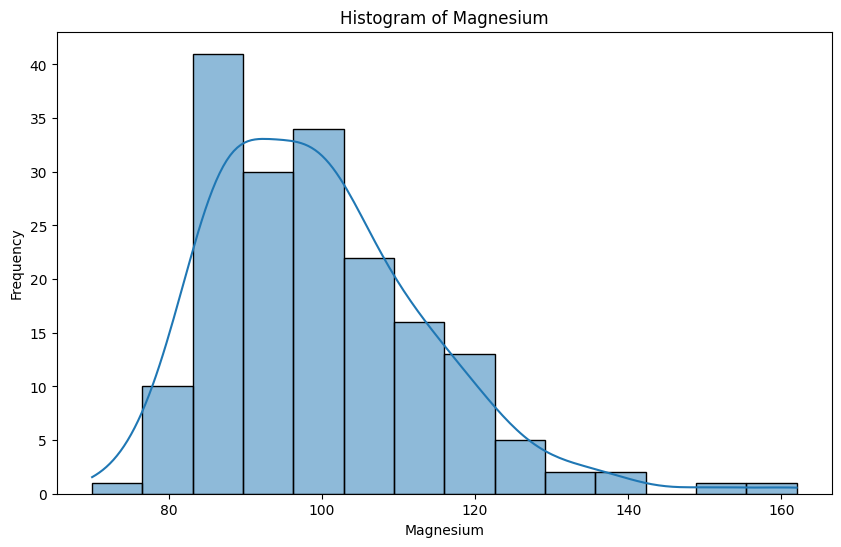

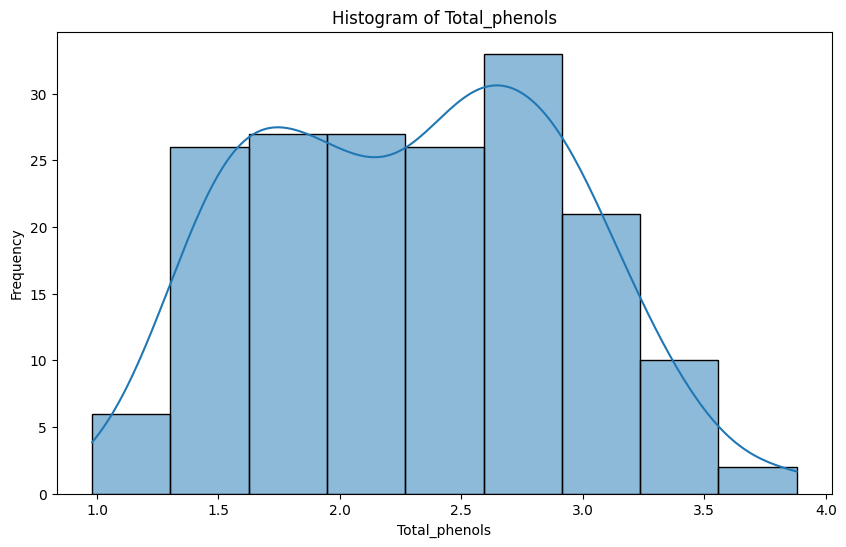

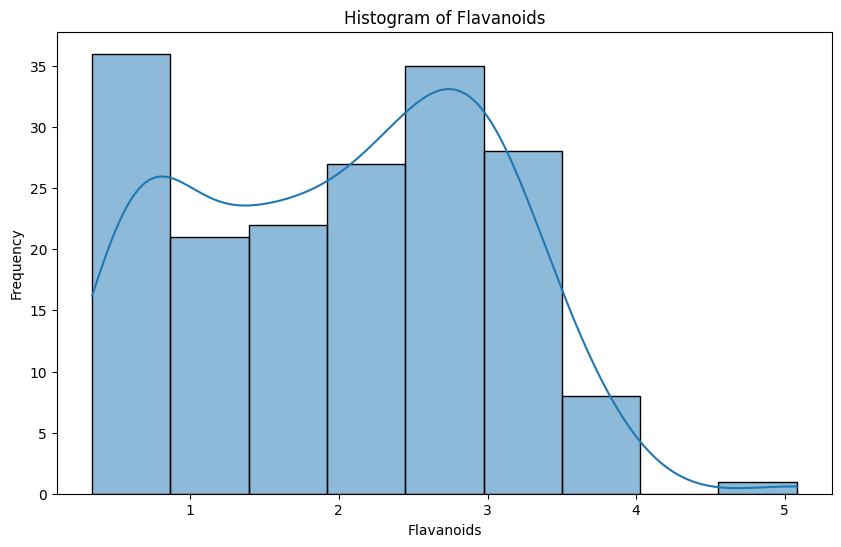

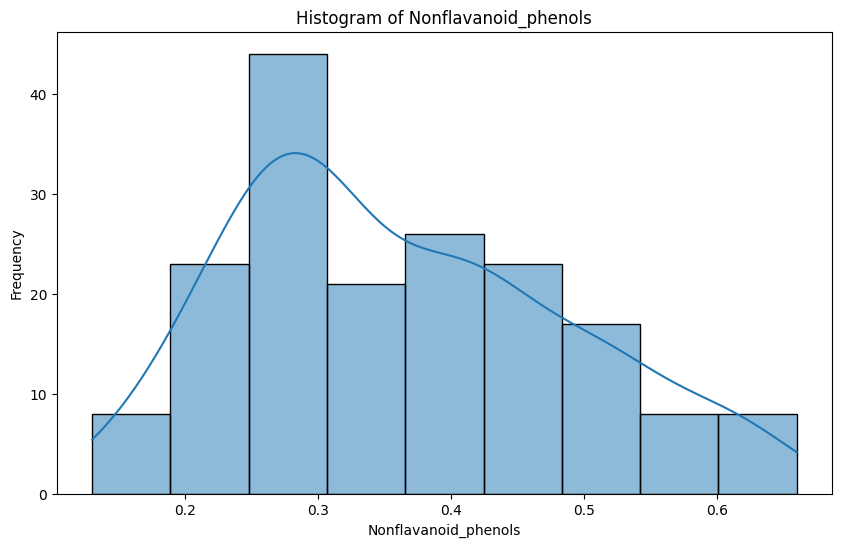

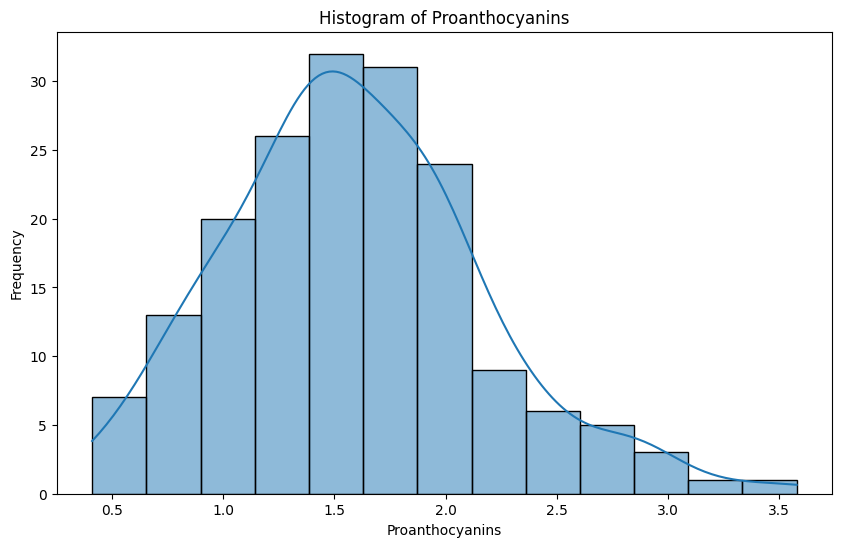

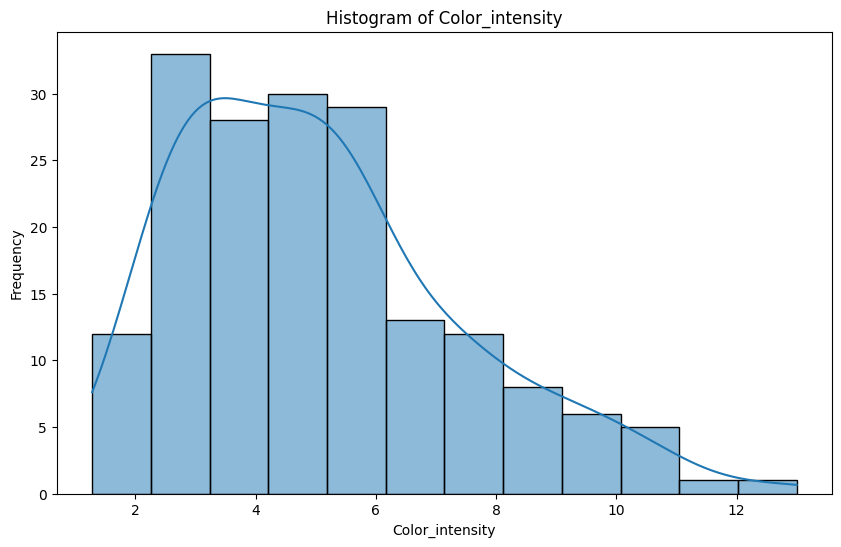

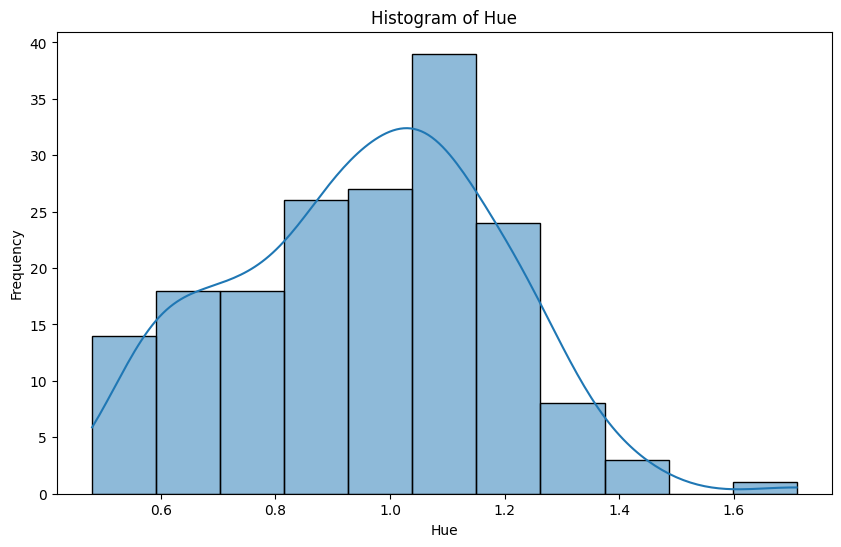

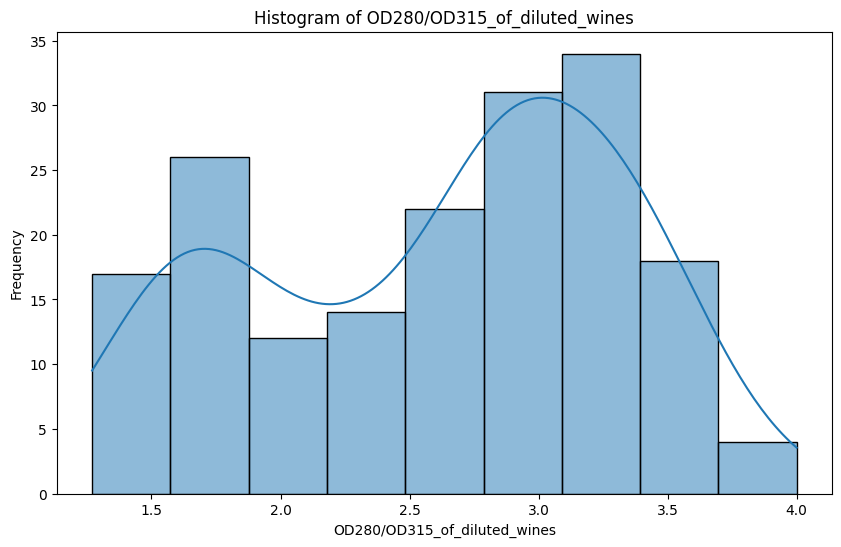

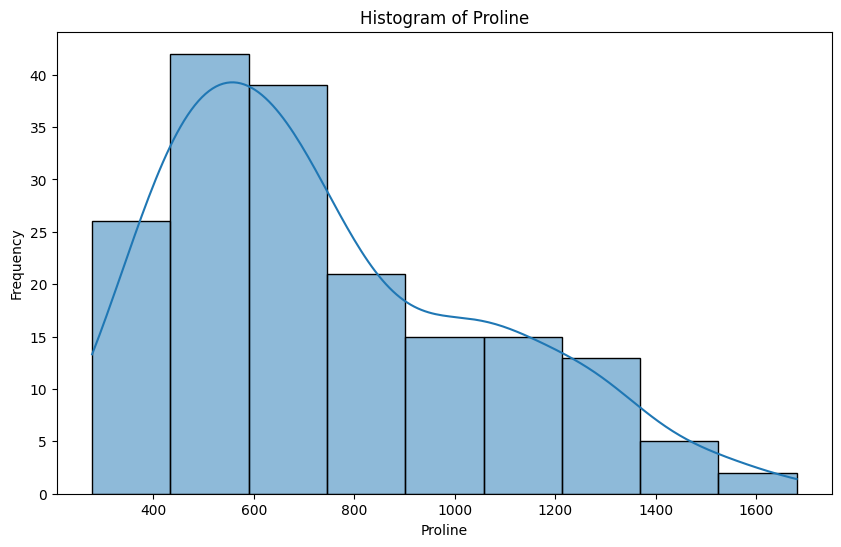


Data types after conversion:
 class                             int64
Alcohol                         float64
Malicacid                       float64
Ash                             float64
Alcalinity_of_ash               float64
Magnesium                         int64
Total_phenols                   float64
Flavanoids                      float64
Nonflavanoid_phenols            float64
Proanthocyanins                 float64
Color_intensity                 float64
Hue                             float64
OD280/OD315_of_diluted_wines    float64
Proline                           int64
dtype: object

Final cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malicacid         

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf

# Set the path to the file you'd like to load
file_path = 'wine.data'

# Load the CSV with the correct encoding
df = pd.read_csv(file_path, encoding='utf-8', delimiter=',')

print("First 5 records:\n", df.head())

print("\nEDA Summary:")
print(df.describe())

print("\nHow categorical variables are distributed:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())

print("\nDistribución de la variable objetivo (class):")
print(df['class'].value_counts())
print(f"Porcentaje de class: {df['class'].mean()*100:.2f}%")

print("\nMissing values per column:\n", df.isnull().sum())

print("\nData types:\n", df.dtypes)

print("\nDataFrame shape after deletion:", df.shape)

print("\nColumn names:", df.columns.tolist())

print("\nDeleting rows with any missing values...")
df = df.dropna()

print("\nDataFrame shape after deleting rows with missing values:", df.shape)

print("\nDeleting duplicate rows...")
df = df.drop_duplicates()

print("\nDataFrame shape after deleting duplicate rows:", df.shape)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\nMatrix of correlations:\n")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()
    
print("\nPlotting hist plots for numeric columns...")
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    
print("\nData types after conversion:\n", df.dtypes)

print("\nFinal cleaned DataFrame info:")
print(df.info())

print("\nFirst 5 records of cleaned DataFrame:\n", df.head())

print("\nData cleaning completed.")
print("\n" + "="*80)
print("INFORMACIÓN DEL DATASET")
print("="*80)
print(f"Total de registros: {len(df)}")
print(f"Total de características: {len(df.columns) - 1}")
print(f"\nDistribución por clase:")
print(df['class'].value_counts().sort_index())
print("\nNOTA: El dataset Wine es relativamente pequeño (178 registros) y las clases")
print("están bien separadas, por lo que algunos modelos pueden alcanzar alta precisión.")
print("El shuffle está ACTIVADO por defecto en train_test_split.")
print("\nNOTA: El escalado se realizará después de la separación train/test en cada modelo.")


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 1 (1 característica)...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 1 en Test:
  Pérdida: 0.4298
  Accuracy: 0.8056
  Precision: 0.8056
  Recall: 0.8056
  F1-Score: 0.8055
  Épocas entrenadas: 66


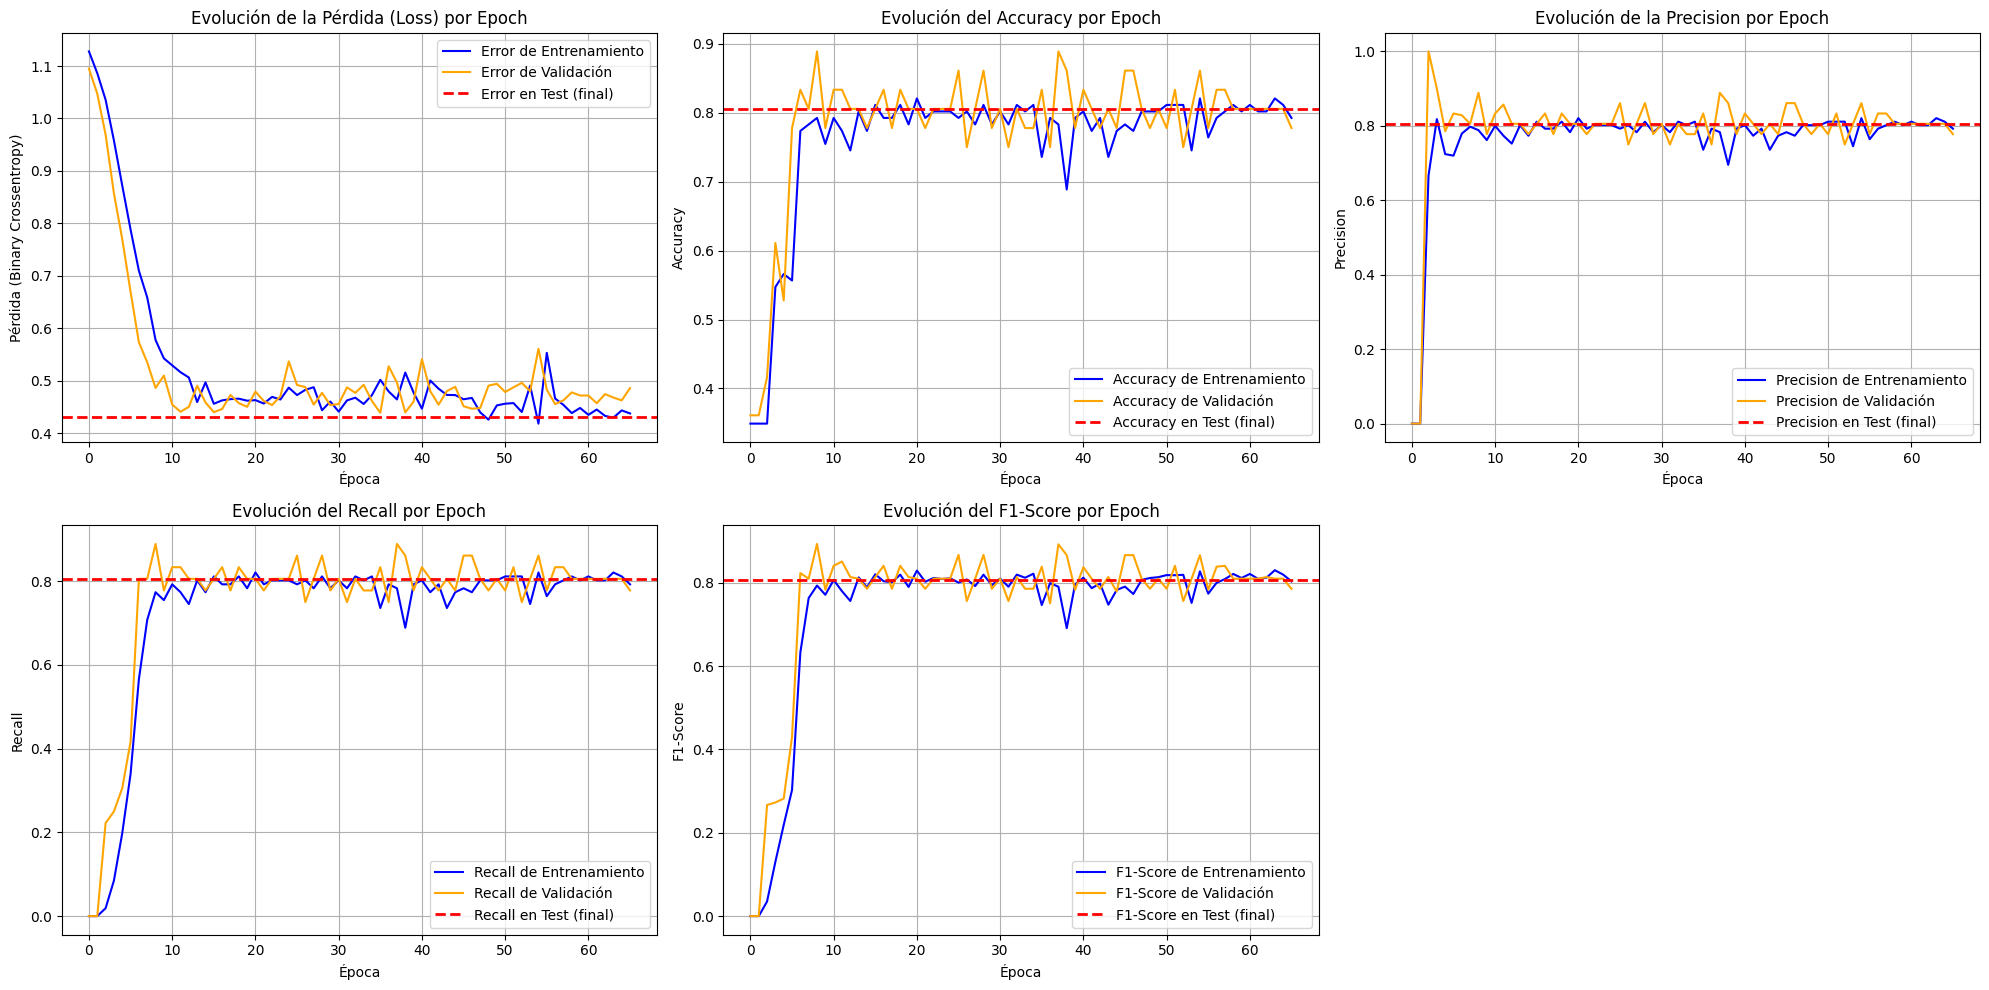

In [2]:
X = df[['Flavanoids']]
y = tf.keras.utils.to_categorical(df['class'] - 1)

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
# Primera división: separar test (20%)
X_temp, X_test_1, y_temp, y_test_1 = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp)

print(f"Train: {len(X_train_1)} | Validation: {len(X_val_1)} | Test: {len(X_test_1)}")

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_1 = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_1_scaled = scaler_X_1.fit_transform(X_train_1)

# Solo transformar validation y test (sin fit)
X_val_1_scaled = scaler_X_1.transform(X_val_1)
X_test_1_scaled = scaler_X_1.transform(X_test_1)

# Modelo Simple - Clasificación Multiclase
model_1 = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_1_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida - Clasificación multiclase con softmax
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_1.compile(optimizer=tf.keras.optimizers.Adam(0.01), 
                loss='categorical_crossentropy',
                metrics=['accuracy', 
                         tf.keras.metrics.Precision(name='precision'),
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)])

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print('Entrenando Modelo 1 (1 característica)...')
history_1 = model_1.fit(X_train_1_scaled, y_train_1, epochs=200, validation_data=(X_val_1_scaled, y_val_1), 
                        callbacks=[early_stop], verbose=0)

# Evaluación final con el conjunto de TEST
results_1 = model_1.evaluate(X_test_1_scaled, y_test_1, verbose=0)
loss_1, accuracy_1, precision_1, recall_1, f1_1 = results_1
print(f'Métricas Modelo 1 en Test:')
print(f'  Pérdida: {loss_1:.4f}')
print(f'  Accuracy: {accuracy_1:.4f}')
print(f'  Precision: {precision_1:.4f}')
print(f'  Recall: {recall_1:.4f}')
print(f'  F1-Score: {f1_1:.4f}')
print(f'  Épocas entrenadas: {len(history_1.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_1.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_1.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_1, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_1.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_1.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_1, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_1.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_1.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_1, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_1.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_1.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_1, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_1.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_1.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_1, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 2 (Múltiples características)...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 2 en Test:
  Pérdida: 0.4405
  Accuracy: 0.7500
  Precision: 0.7500
  Recall: 0.7500
  F1-Score: 0.7565
  Épocas entrenadas: 46


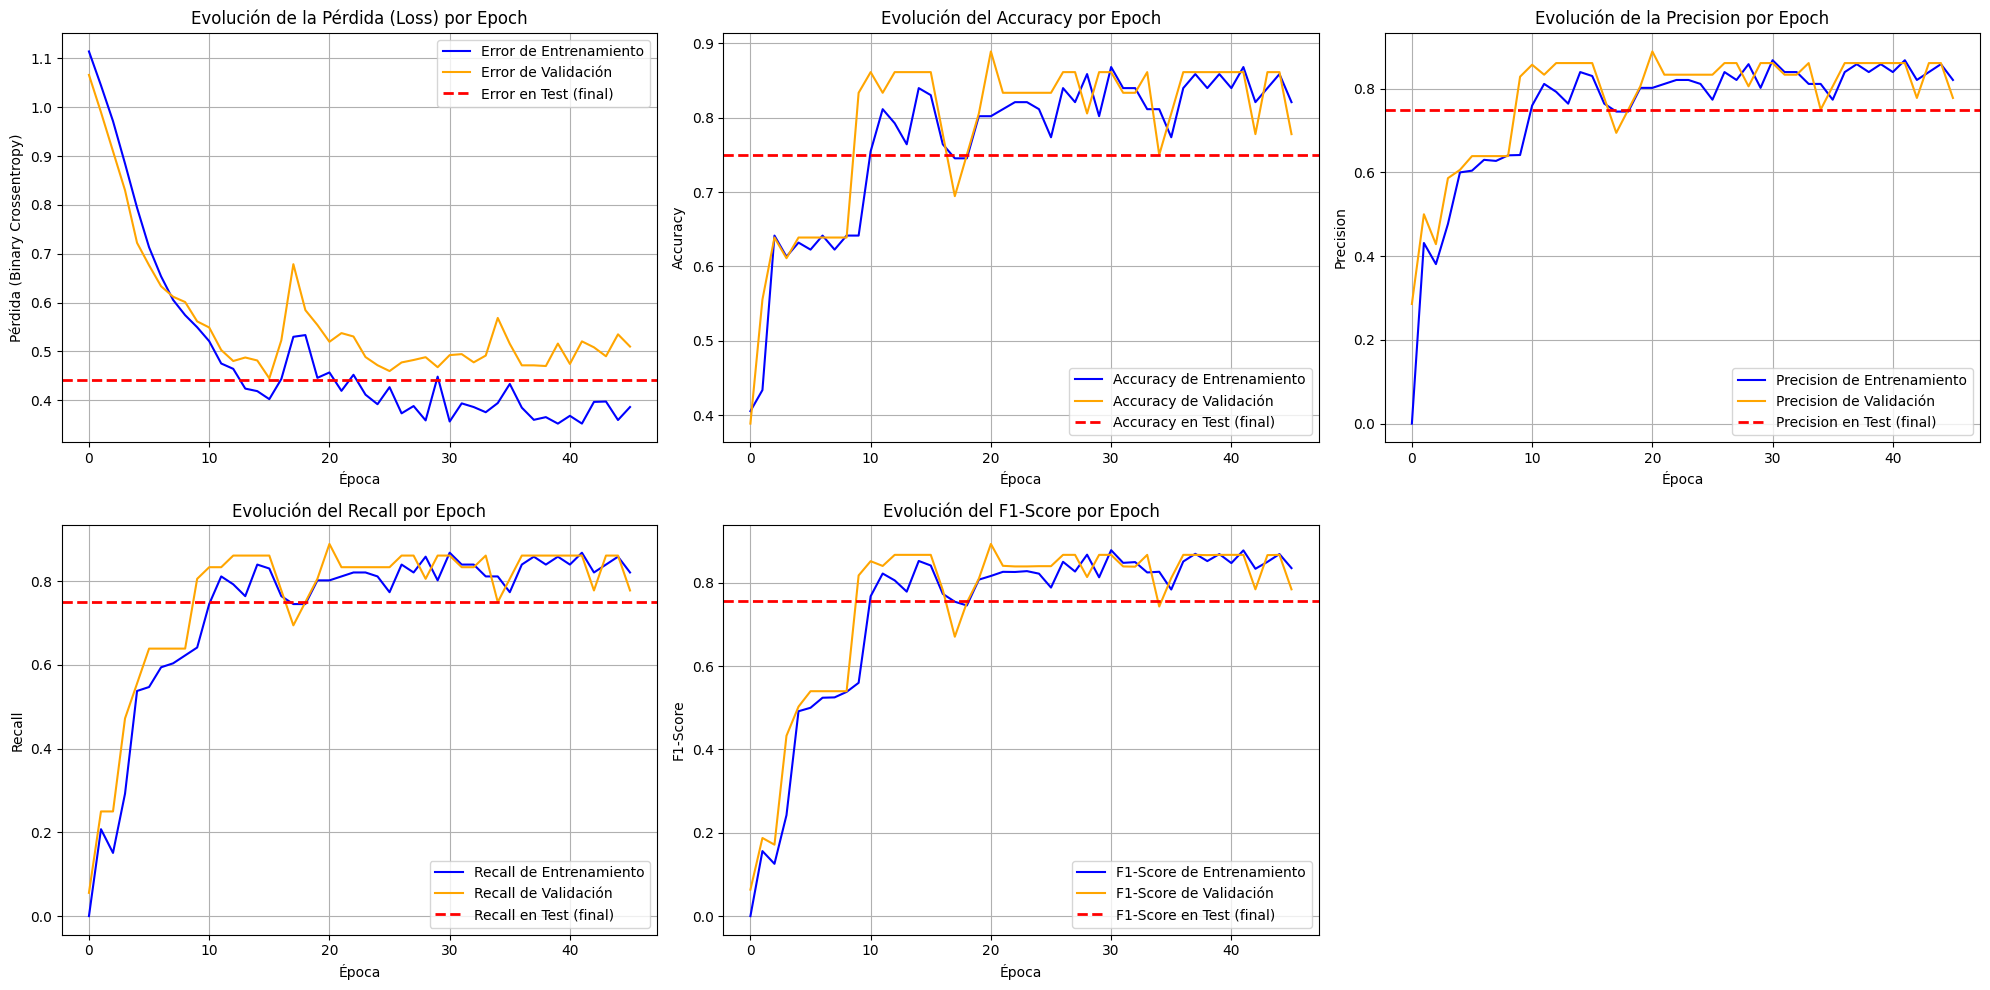

In [3]:
X = df[['Flavanoids', 'OD280/OD315_of_diluted_wines']]
y = tf.keras.utils.to_categorical(df['class'] - 1)

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
# Primera división: separar test (20%)
X_temp, X_test_M, y_temp, y_test_M = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_M, X_val_M, y_train_M, y_val_M = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp)

print(f"Train: {len(X_train_M)} | Validation: {len(X_val_M)} | Test: {len(X_test_M)}")

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_M = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_M_scaled = scaler_X_M.fit_transform(X_train_M)

# Solo transformar validation y test (sin fit)
X_val_M_scaled = scaler_X_M.transform(X_val_M)
X_test_M_scaled = scaler_X_M.transform(X_test_M)

# Modelo Multivariable - Clasificación Multiclase
model_M = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_M_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida - Clasificación Multiclase con softmax
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_M.compile(optimizer=tf.keras.optimizers.Adam(0.01), 
                loss='categorical_crossentropy',
                metrics=['accuracy', 
                         tf.keras.metrics.Precision(name='precision'),
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)])

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print('Entrenando Modelo 2 (Múltiples características)...')
history_M = model_M.fit(X_train_M_scaled, y_train_M, epochs=200, validation_data=(X_val_M_scaled, y_val_M),
                        callbacks=[early_stop], verbose=0)

# Evaluación final con el conjunto de TEST
results_M = model_M.evaluate(X_test_M_scaled, y_test_M, verbose=0)
loss_M, accuracy_M, precision_M, recall_M, f1_M = results_M
print(f'Métricas Modelo 2 en Test:')
print(f'  Pérdida: {loss_M:.4f}')
print(f'  Accuracy: {accuracy_M:.4f}')
print(f'  Precision: {precision_M:.4f}')
print(f'  Recall: {recall_M:.4f}')
print(f'  F1-Score: {f1_M:.4f}')
print(f'  Épocas entrenadas: {len(history_M.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_M.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_M, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_M.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_M.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_M, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_M.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_M.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_M, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_M.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_M.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_M, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_M.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_M.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_M, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 3 (Todas las características)...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 3 en Test:
  Pérdida: 0.0217
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Épocas entrenadas: 138


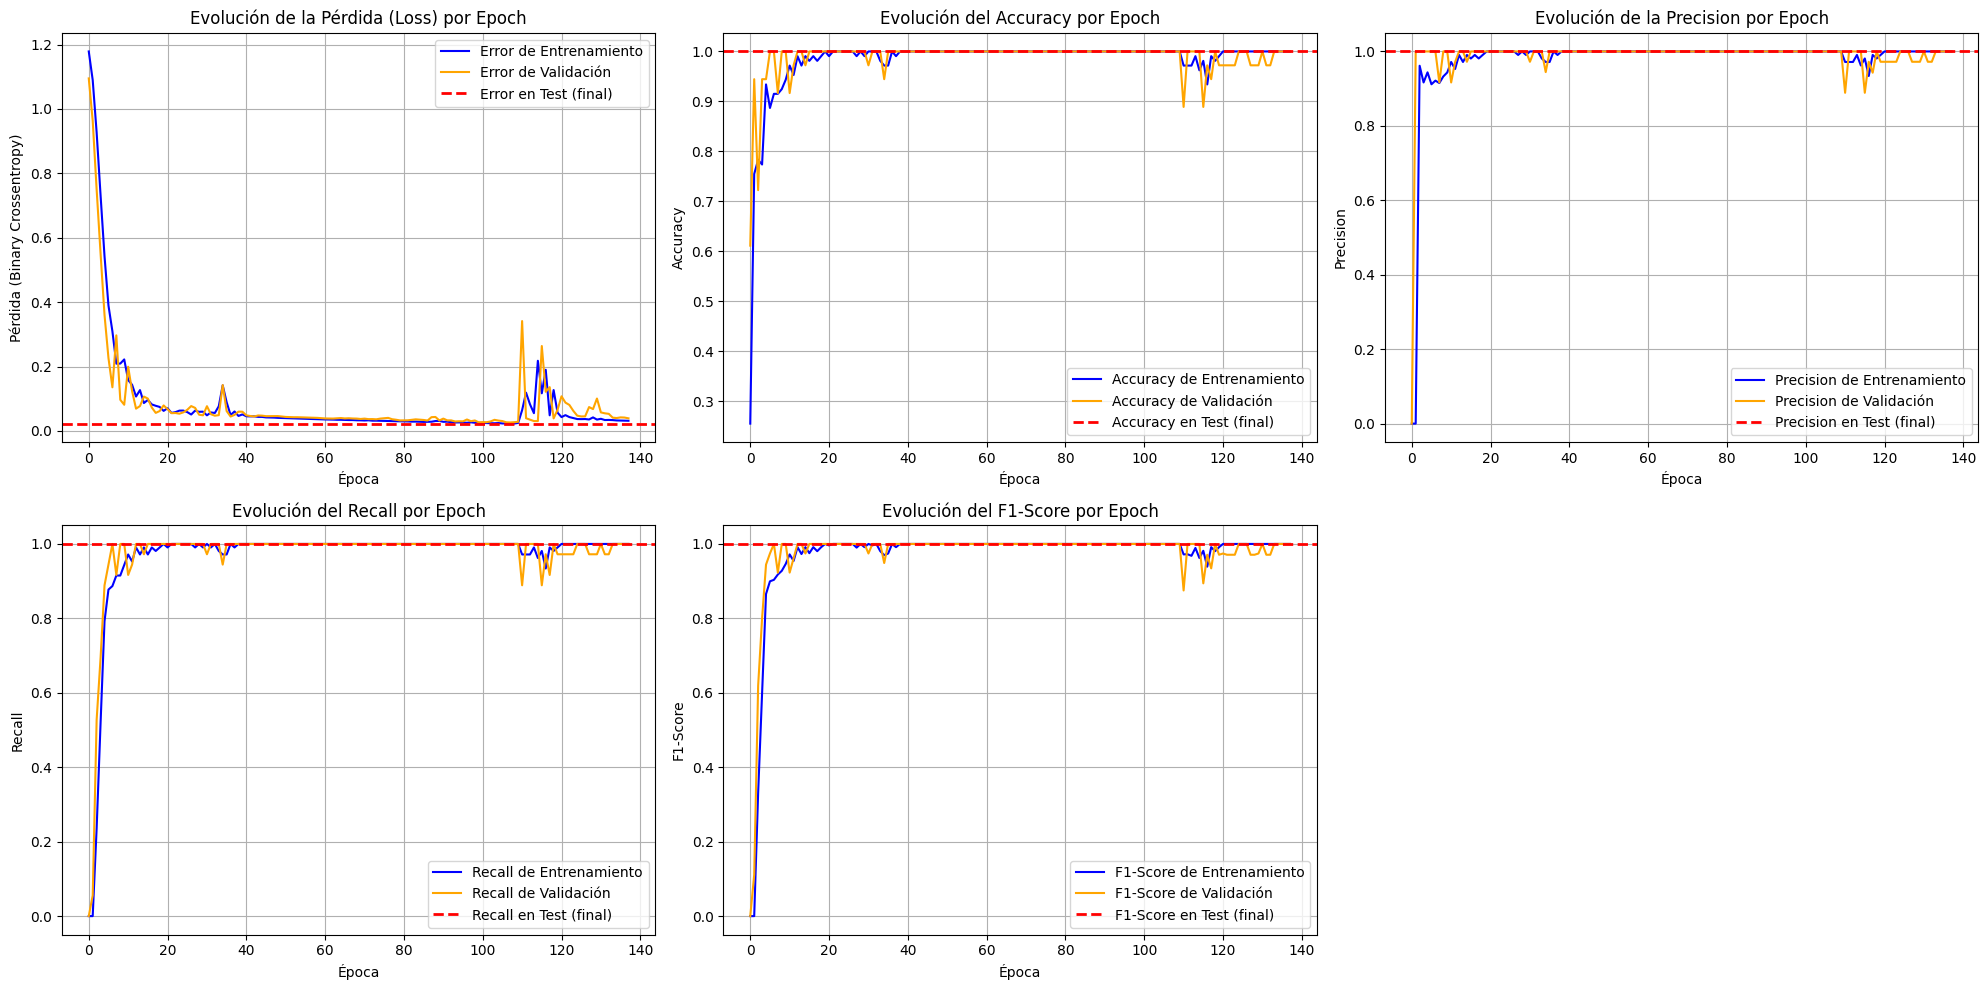

In [4]:
X = df.drop(columns=['class'])
y = tf.keras.utils.to_categorical(df['class'] - 1)

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
# Primera división: separar test (20%)
X_temp, X_test_M_all, y_temp, y_test_M_all = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_M_all, X_val_M_all, y_train_M_all, y_val_M_all = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp)

print(f"Train: {len(X_train_M_all)} | Validation: {len(X_val_M_all)} | Test: {len(X_test_M_all)}")

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_M_all = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_M_all_scaled = scaler_X_M_all.fit_transform(X_train_M_all)

# Solo transformar validation y test (sin fit)
X_val_M_all_scaled = scaler_X_M_all.transform(X_val_M_all)
X_test_M_all_scaled = scaler_X_M_all.transform(X_test_M_all)

# Modelo Multivariable - Clasificación Multiclase
model_M_all = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_M_all_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida - Clasificación Multiclase con softmax
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_M_all.compile(optimizer=tf.keras.optimizers.Adam(0.01), 
                    loss='categorical_crossentropy',
                    metrics=['accuracy', 
                             tf.keras.metrics.Precision(name='precision'),
                             tf.keras.metrics.Recall(name='recall'),
                             tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)])

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print('Entrenando Modelo 3 (Todas las características)...')
history_M_all = model_M_all.fit(X_train_M_all_scaled, y_train_M_all, epochs=200, validation_data=(X_val_M_all_scaled, y_val_M_all),
                                callbacks=[early_stop], verbose=0)

# Evaluación final con el conjunto de TEST
results_M_all = model_M_all.evaluate(X_test_M_all_scaled, y_test_M_all, verbose=0)
loss_M_all, accuracy_M_all, precision_M_all, recall_M_all, f1_M_all = results_M_all
print(f'Métricas Modelo 3 en Test:')
print(f'  Pérdida: {loss_M_all:.4f}')
print(f'  Accuracy: {accuracy_M_all:.4f}')
print(f'  Precision: {precision_M_all:.4f}')
print(f'  Recall: {recall_M_all:.4f}')
print(f'  F1-Score: {f1_M_all:.4f}')
print(f'  Épocas entrenadas: {len(history_M_all.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_M_all.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M_all.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_M_all, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_M_all.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_M_all.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_M_all, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_M_all.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_M_all.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_M_all, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_M_all.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_M_all.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_M_all, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_M_all.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_M_all.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_M_all, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 4 (1 característica con Dropout)...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 4 en Test:
  Pérdida: 0.4672
  Accuracy: 0.7778
  Precision: 0.7778
  Recall: 0.7778
  F1-Score: 0.7770
  Épocas entrenadas: 52


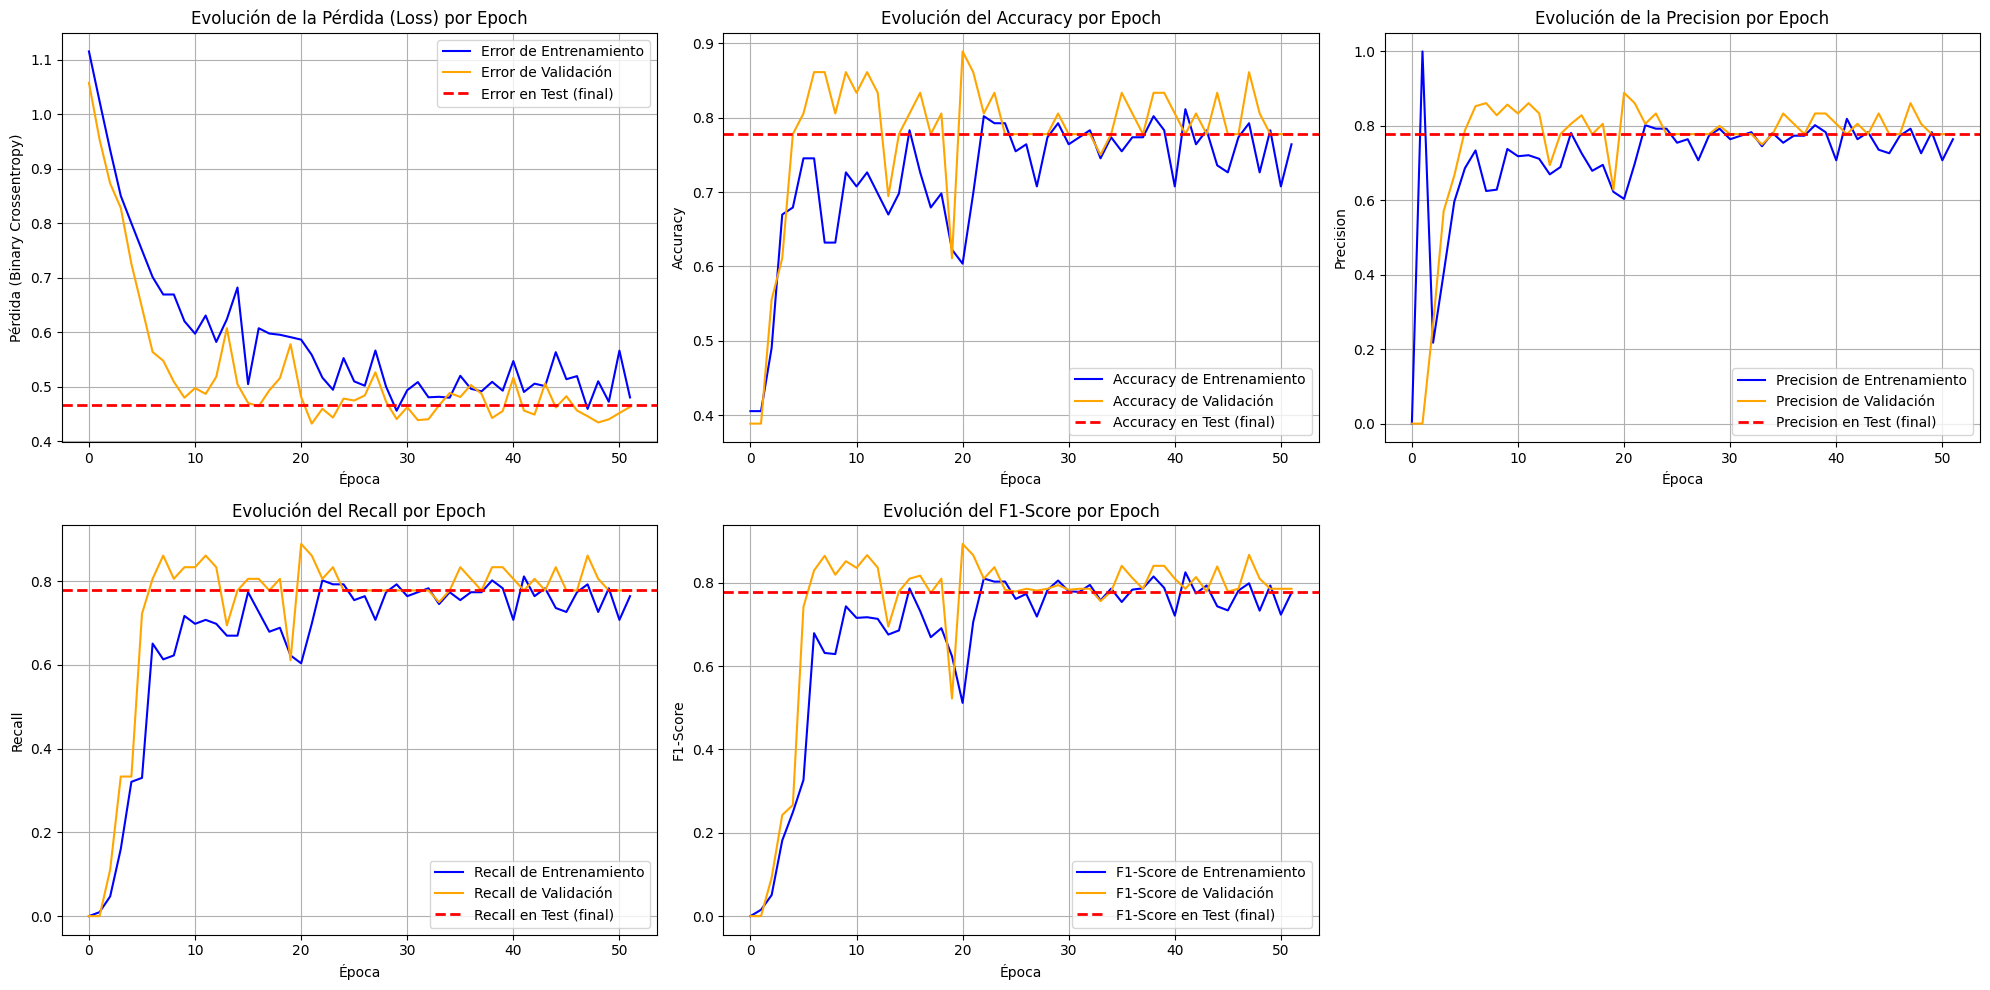

In [5]:
X = df[['Flavanoids']]
y = tf.keras.utils.to_categorical(df['class'] - 1)

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
# Primera división: separar test (20%)
X_temp, X_test_1_a, y_temp, y_test_1_a = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_1_a, X_val_1_a, y_train_1_a, y_val_1_a = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp)

print(f"Train: {len(X_train_1_a)} | Validation: {len(X_val_1_a)} | Test: {len(X_test_1_a)}")

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_1_a = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_1_a_scaled = scaler_X_1_a.fit_transform(X_train_1_a)

# Solo transformar validation y test (sin fit)
X_val_1_a_scaled = scaler_X_1_a.transform(X_val_1_a)
X_test_1_a_scaled = scaler_X_1_a.transform(X_test_1_a)

# Modelo Simple con Dropout - Clasificación Multiclase
model_1_a = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_1_a_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida - Clasificación Multiclase con softmax
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_1_a.compile(optimizer=tf.keras.optimizers.Adam(0.01), 
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)])

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print('Entrenando Modelo 4 (1 característica con Dropout)...')
history_1_a = model_1_a.fit(X_train_1_a_scaled, y_train_1_a, epochs=200, validation_data=(X_val_1_a_scaled, y_val_1_a),
                            callbacks=[early_stop], verbose=0)

# Evaluación final con el conjunto de TEST
results_1_a = model_1_a.evaluate(X_test_1_a_scaled, y_test_1_a, verbose=0)
loss_1_a, accuracy_1_a, precision_1_a, recall_1_a, f1_1_a = results_1_a
print(f'Métricas Modelo 4 en Test:')
print(f'  Pérdida: {loss_1_a:.4f}')
print(f'  Accuracy: {accuracy_1_a:.4f}')
print(f'  Precision: {precision_1_a:.4f}')
print(f'  Recall: {recall_1_a:.4f}')
print(f'  F1-Score: {f1_1_a:.4f}')
print(f'  Épocas entrenadas: {len(history_1_a.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_1_a.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_1_a.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_1_a, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_1_a.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_1_a.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_1_a, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_1_a.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_1_a.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_1_a, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_1_a.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_1_a.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_1_a, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_1_a.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_1_a.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_1_a, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 5 (Múltiples características con Dropout)...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 5 en Test:
  Pérdida: 0.3954
  Accuracy: 0.8611
  Precision: 0.8611
  Recall: 0.8611
  F1-Score: 0.8630
  Épocas entrenadas: 76


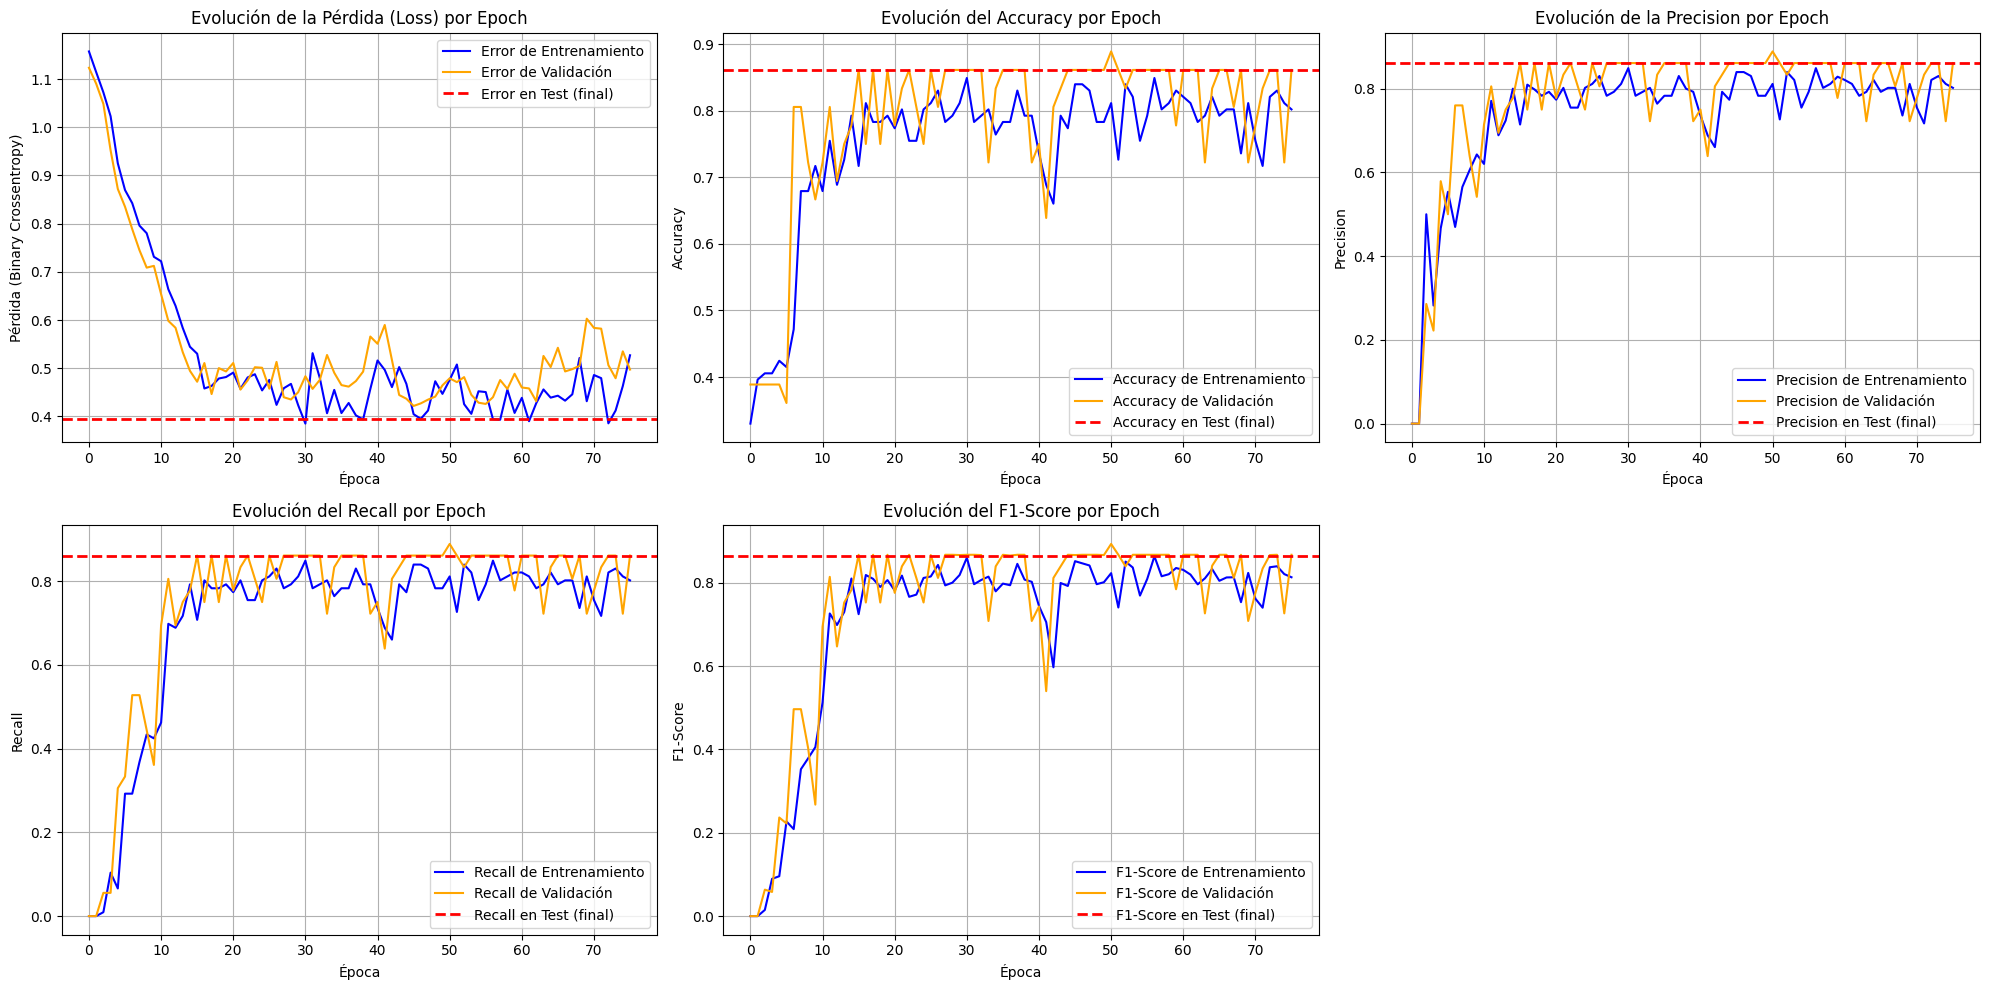

In [6]:
X = df[['Flavanoids', 'OD280/OD315_of_diluted_wines']]
y = tf.keras.utils.to_categorical(df['class'] - 1)

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
# Primera división: separar test (20%)
X_temp, X_test_M_a, y_temp, y_test_M_a = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_M_a, X_val_M_a, y_train_M_a, y_val_M_a = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp)

print(f"Train: {len(X_train_M_a)} | Validation: {len(X_val_M_a)} | Test: {len(X_test_M_a)}")

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_M_a = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_M_a_scaled = scaler_X_M_a.fit_transform(X_train_M_a)

# Solo transformar validation y test (sin fit)
X_val_M_a_scaled = scaler_X_M_a.transform(X_val_M_a)
X_test_M_a_scaled = scaler_X_M_a.transform(X_test_M_a)

# Modelo Multivariable con Dropout - Clasificación Multiclase
model_M_a = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_M_a_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida - Clasificación Multiclase con softmax
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_M_a.compile(optimizer=tf.keras.optimizers.Adam(0.01), 
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)])

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print('Entrenando Modelo 5 (Múltiples características con Dropout)...')
history_M_a = model_M_a.fit(X_train_M_a_scaled, y_train_M_a, epochs=200, validation_data=(X_val_M_a_scaled, y_val_M_a),
                            callbacks=[early_stop], verbose=0)

# Evaluación final con el conjunto de TEST
results_M_a = model_M_a.evaluate(X_test_M_a_scaled, y_test_M_a, verbose=0)
loss_M_a, accuracy_M_a, precision_M_a, recall_M_a, f1_M_a = results_M_a
print(f'Métricas Modelo 5 en Test:')
print(f'  Pérdida: {loss_M_a:.4f}')
print(f'  Accuracy: {accuracy_M_a:.4f}')
print(f'  Precision: {precision_M_a:.4f}')
print(f'  Recall: {recall_M_a:.4f}')
print(f'  F1-Score: {f1_M_a:.4f}')
print(f'  Épocas entrenadas: {len(history_M_a.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_M_a.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M_a.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_M_a, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_M_a.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_M_a.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_M_a, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_M_a.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_M_a.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_M_a, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_M_a.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_M_a.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_M_a, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_M_a.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_M_a.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_M_a, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 6 (Todas las características con Dropout)...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 6 en Test:
  Pérdida: 0.0460
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Épocas entrenadas: 88


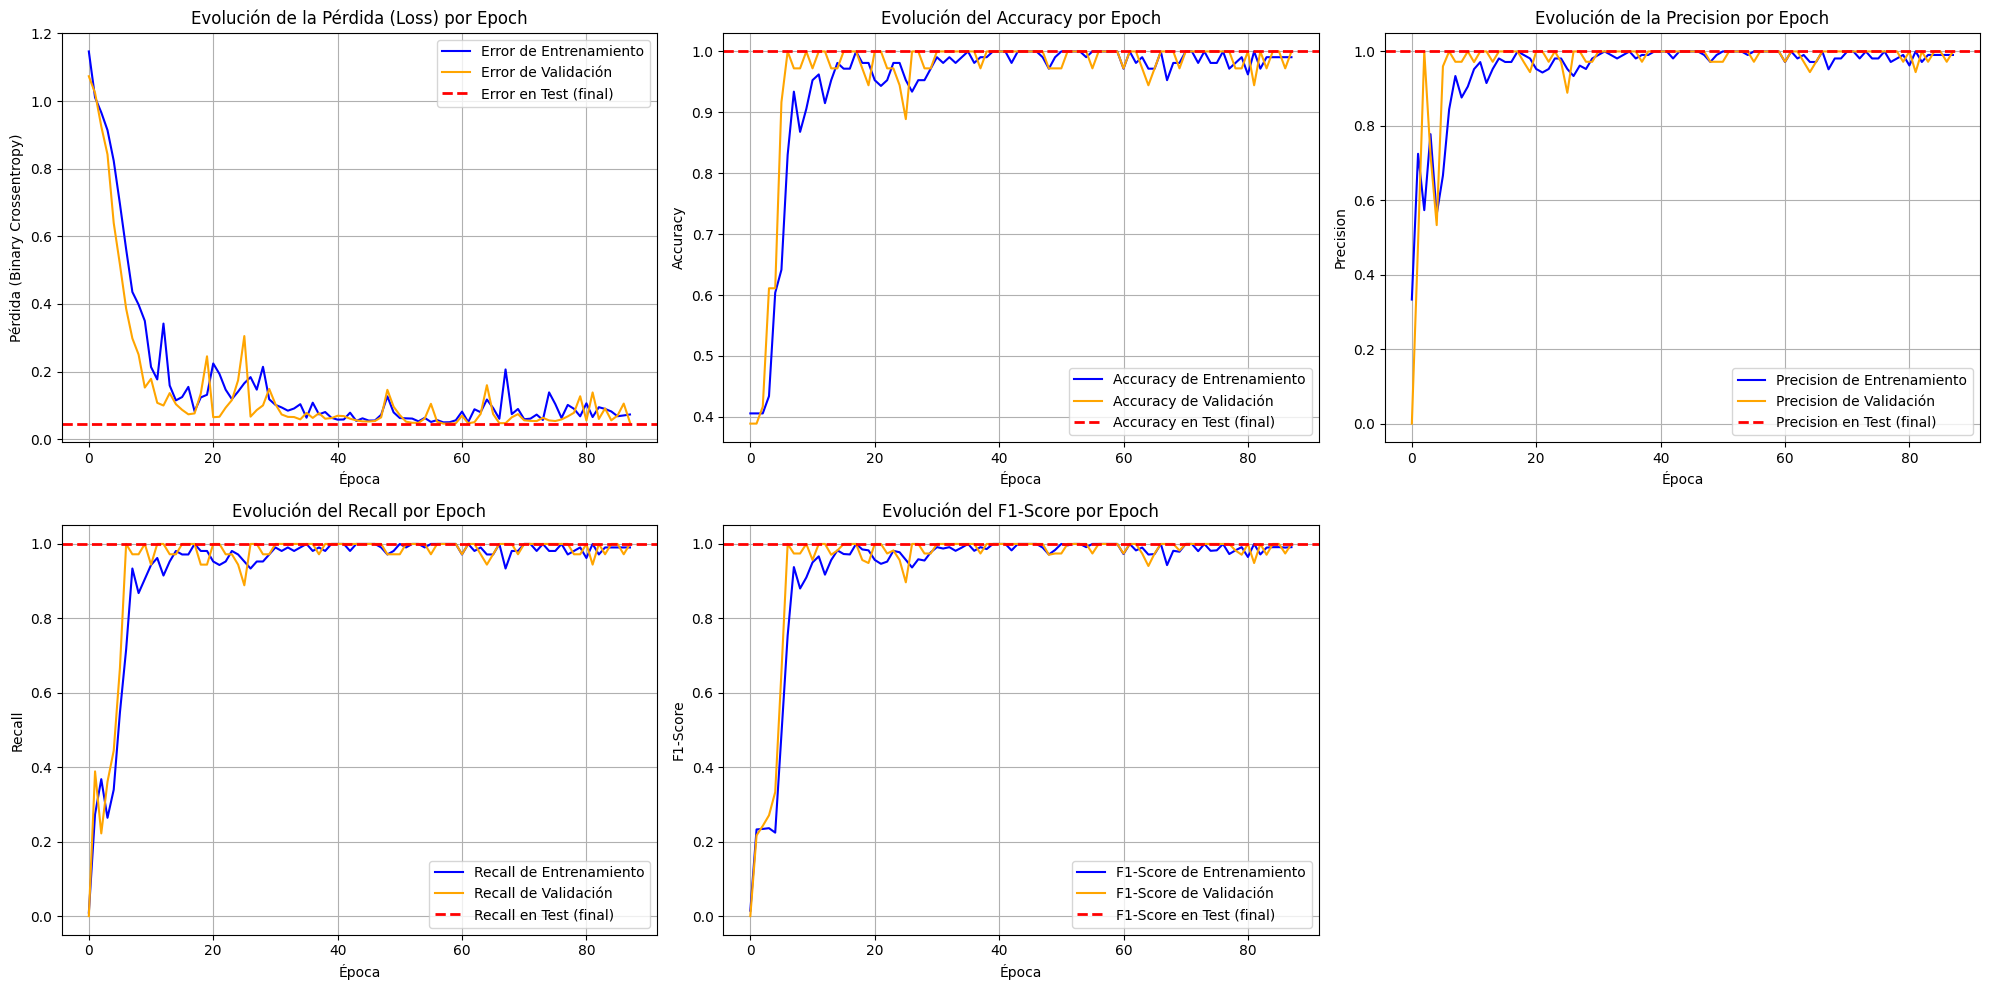

In [7]:
X = df.drop(columns=['class'])
y = tf.keras.utils.to_categorical(df['class'] - 1)

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
# Primera división: separar test (20%)
X_temp, X_test_M_a_all, y_temp, y_test_M_a_all = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)

# Segunda división: train (75% de temp = 60% total) y validation (25% de temp = 20% total)
X_train_M_a_all, X_val_M_a_all, y_train_M_a_all, y_val_M_a_all = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp)

print(f"Train: {len(X_train_M_a_all)} | Validation: {len(X_val_M_a_all)} | Test: {len(X_test_M_a_all)}")

# Escalado DESPUÉS de la separación, solo con datos de entrenamiento
print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_X_M_a_all = MinMaxScaler()

# Ajustar y transformar entrenamiento
X_train_M_a_all_scaled = scaler_X_M_a_all.fit_transform(X_train_M_a_all)

# Solo transformar validation y test (sin fit)
X_val_M_a_all_scaled = scaler_X_M_a_all.transform(X_val_M_a_all)
X_test_M_a_all_scaled = scaler_X_M_a_all.transform(X_test_M_a_all)

# Modelo Multivariable con Dropout - Clasificación Multiclase
model_M_a_all = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[X_train_M_a_all_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida - Clasificación Multiclase con softmax
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_M_a_all.compile(optimizer=tf.keras.optimizers.Adam(0.01), 
                      loss='categorical_crossentropy',
                      metrics=['accuracy', 
                               tf.keras.metrics.Precision(name='precision'),
                               tf.keras.metrics.Recall(name='recall'),
                               tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)])

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print('Entrenando Modelo 6 (Todas las características con Dropout)...')
history_M_a_all = model_M_a_all.fit(X_train_M_a_all_scaled, y_train_M_a_all, epochs=200, validation_data=(X_val_M_a_all_scaled, y_val_M_a_all),
                                    callbacks=[early_stop], verbose=0)

# Evaluación final con el conjunto de TEST
results_M_a_all = model_M_a_all.evaluate(X_test_M_a_all_scaled, y_test_M_a_all, verbose=0)
loss_M_a_all, accuracy_M_a_all, precision_M_a_all, recall_M_a_all, f1_M_a_all = results_M_a_all
print(f'Métricas Modelo 6 en Test:')
print(f'  Pérdida: {loss_M_a_all:.4f}')
print(f'  Accuracy: {accuracy_M_a_all:.4f}')
print(f'  Precision: {precision_M_a_all:.4f}')
print(f'  Recall: {recall_M_a_all:.4f}')
print(f'  F1-Score: {f1_M_a_all:.4f}')
print(f'  Épocas entrenadas: {len(history_M_a_all.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_M_a_all.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_M_a_all.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_M_a_all, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_M_a_all.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_M_a_all.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_M_a_all, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_M_a_all.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_M_a_all.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_M_a_all, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_M_a_all.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_M_a_all.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_M_a_all, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_M_a_all.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_M_a_all.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_M_a_all, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Modelos Optimizados para Métricas Específicas

Ahora vamos a entrenar modelos que **priorizan métricas específicas** usando técnicas como:
- **class_weight**: Para dar más importancia a una clase (falsos negativos vs falsos positivos)
- **Umbrales personalizados**: Ajustar el punto de decisión

Crearemos 4 modelos optimizados:
1. **Modelo Base (Accuracy)**: Sin priorización (modelo estándar)
2. **Modelo Optimizado para Recall**: Minimiza falsos negativos (importante para detectar todos los class)
3. **Modelo Optimizado para Precision**: Minimiza falsos positivos (importante para evitar falsas alarmas)
4. **Modelo Optimizado para F1-Score**: Balance óptimo entre precision y recall


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 7 (Optimizado para Accuracy - Sin class_weight)...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 7 en Test:
  Pérdida: 0.0319
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Épocas entrenadas: 168


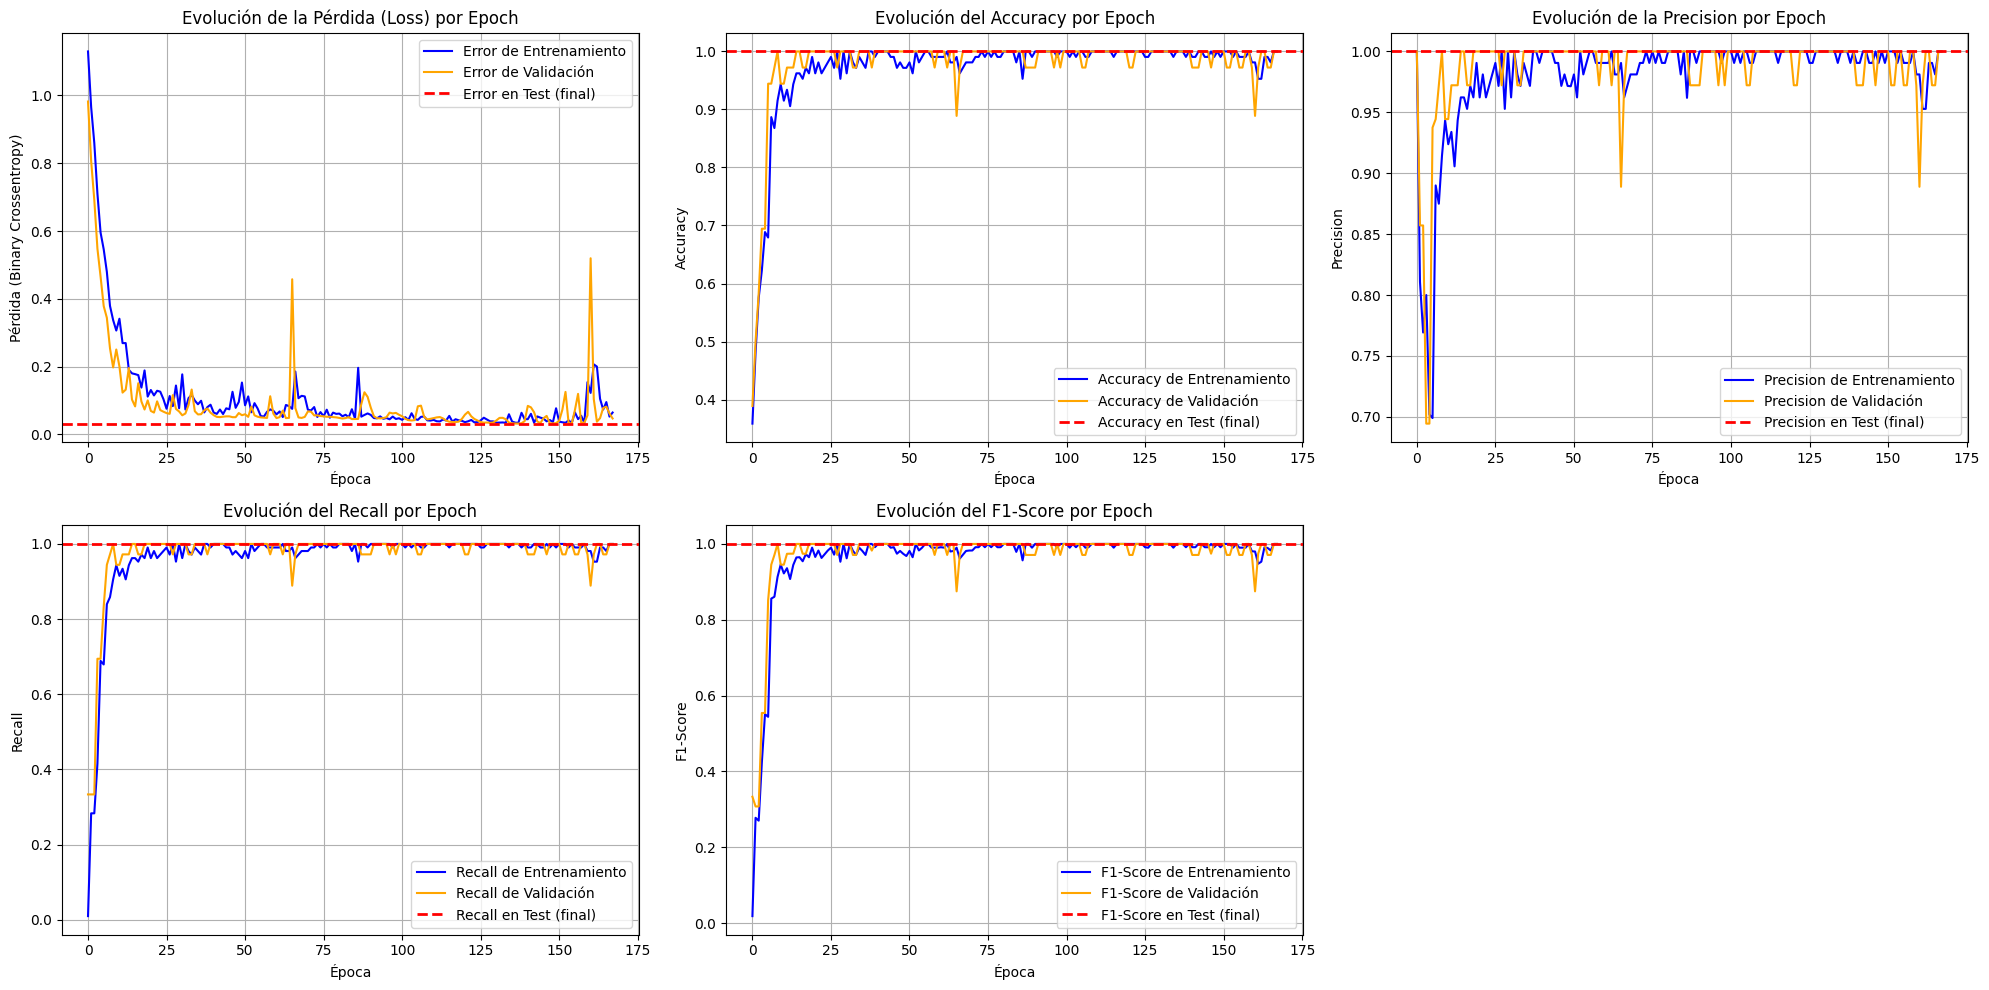

In [8]:
# MODELO 7: OPTIMIZADO PARA ACCURACY (Sin priorización - Modelo Base)
X = df.drop(columns=['class'])
y = tf.keras.utils.to_categorical(df['class'] - 1)

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
X_temp, X_test_opt_acc, y_temp, y_test_opt_acc = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)
X_train_opt_acc, X_val_opt_acc, y_train_opt_acc, y_val_opt_acc = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp)

print(f"Train: {len(X_train_opt_acc)} | Validation: {len(X_val_opt_acc)} | Test: {len(X_test_opt_acc)}")

print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_opt_acc = MinMaxScaler()
X_train_opt_acc_scaled = scaler_opt_acc.fit_transform(X_train_opt_acc)
X_val_opt_acc_scaled = scaler_opt_acc.transform(X_val_opt_acc)
X_test_opt_acc_scaled = scaler_opt_acc.transform(X_test_opt_acc)

model_opt_acc = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, input_shape=[X_train_opt_acc_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.Dense(units=8, activation='relu'),
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_opt_acc.compile(
    optimizer=tf.keras.optimizers.Adam(0.01), 
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)]
)

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print('Entrenando Modelo 7 (Optimizado para Accuracy - Sin class_weight)...')
history_opt_acc = model_opt_acc.fit(
    X_train_opt_acc_scaled, y_train_opt_acc, 
    epochs=200, 
    validation_data=(X_val_opt_acc_scaled, y_val_opt_acc),
    callbacks=[early_stop],
    verbose=0
)

results_opt_acc = model_opt_acc.evaluate(X_test_opt_acc_scaled, y_test_opt_acc, verbose=0)
loss_opt_acc, accuracy_opt_acc, precision_opt_acc, recall_opt_acc, f1_opt_acc = results_opt_acc
print(f'Métricas Modelo 7 en Test:')
print(f'  Pérdida: {loss_opt_acc:.4f}')
print(f'  Accuracy: {accuracy_opt_acc:.4f}')
print(f'  Precision: {precision_opt_acc:.4f}')
print(f'  Recall: {recall_opt_acc:.4f}')
print(f'  F1-Score: {f1_opt_acc:.4f}')
print(f'  Épocas entrenadas: {len(history_opt_acc.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_opt_acc.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_opt_acc.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_opt_acc, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_opt_acc.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_opt_acc.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_opt_acc, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_opt_acc.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_opt_acc.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_opt_acc, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_opt_acc.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_opt_acc.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_opt_acc, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_opt_acc.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_opt_acc.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_opt_acc, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 8 (Optimizado para Recall - class_weight={0: 1.5, 1: 2.0, 2: 1.5})...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 8 en Test:
  Pérdida: 0.0778
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Épocas entrenadas: 120


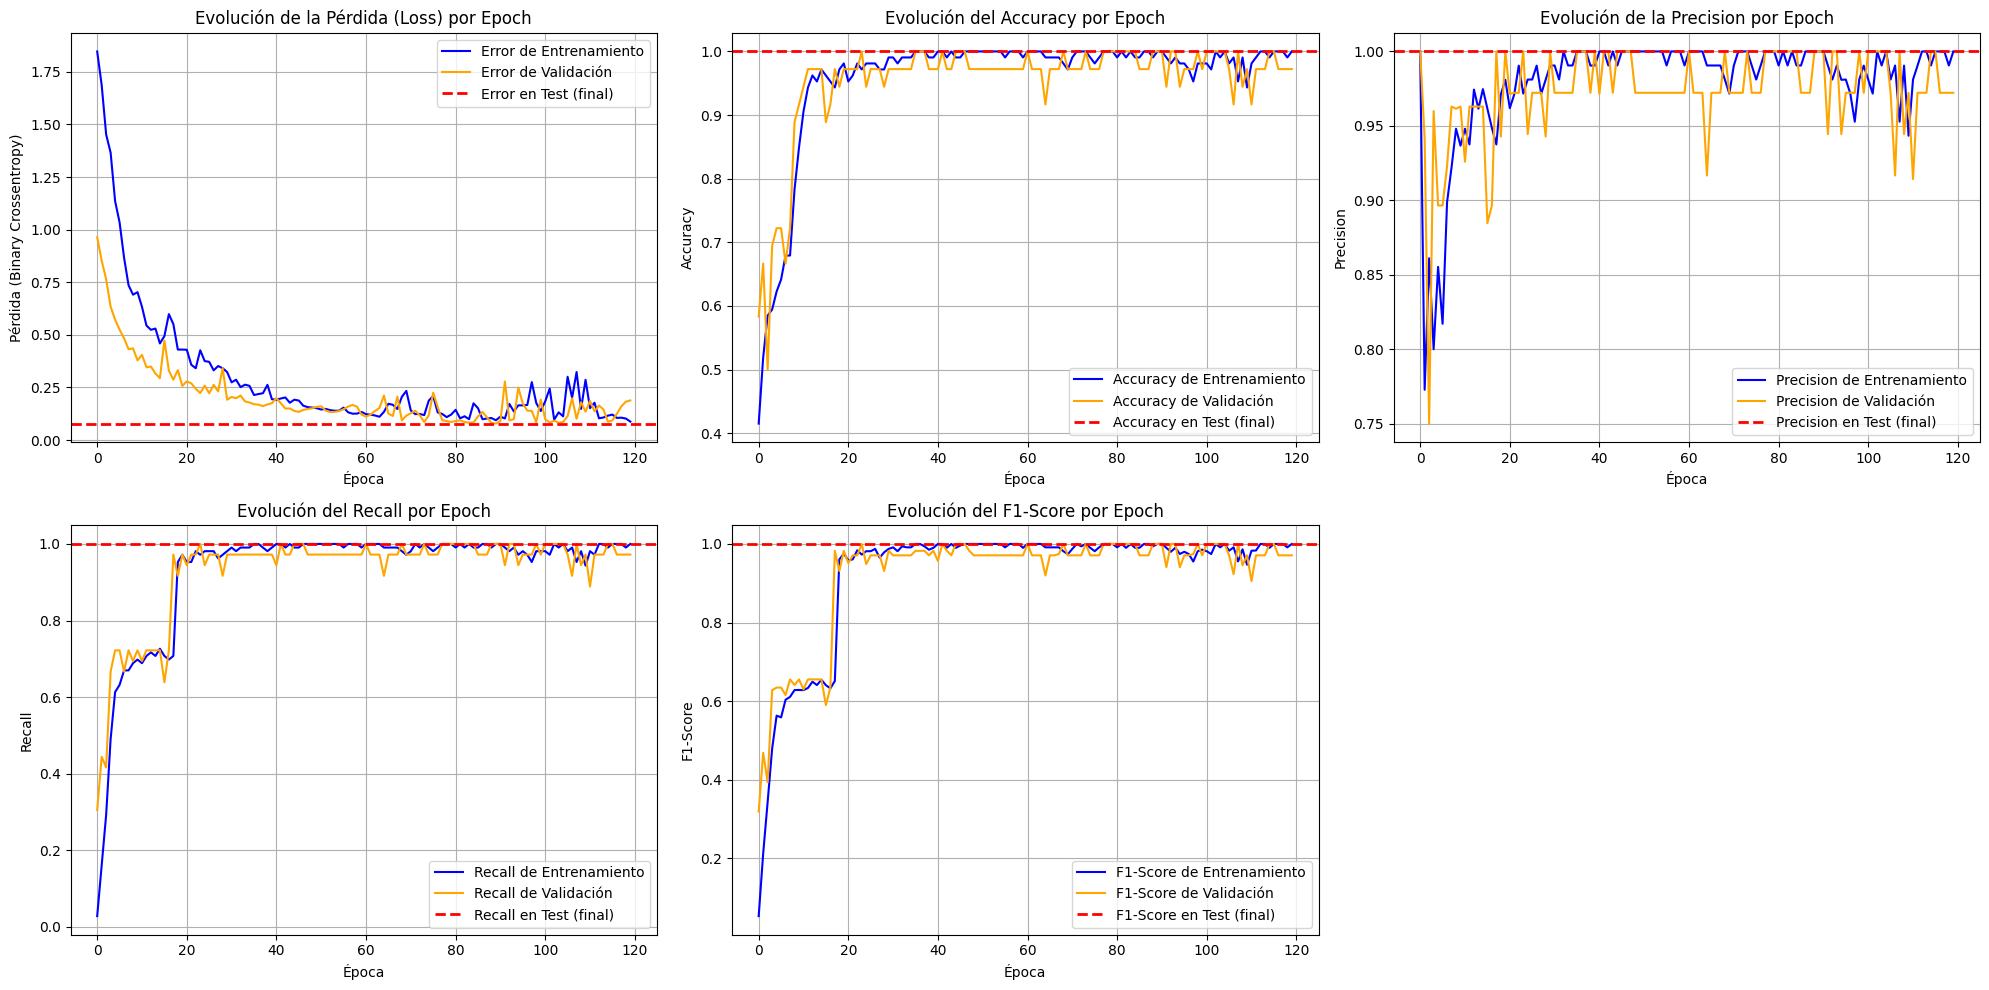

In [9]:
# MODELO 8: OPTIMIZADO PARA RECALL (Detectar más en todas las clases)
X = df.drop(columns=['class'])
y = tf.keras.utils.to_categorical(df['class'] - 1)

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
X_temp, X_test_opt_rec, y_temp, y_test_opt_rec = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)
X_train_opt_rec, X_val_opt_rec, y_train_opt_rec, y_val_opt_rec = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp)

print(f"Train: {len(X_train_opt_rec)} | Validation: {len(X_val_opt_rec)} | Test: {len(X_test_opt_rec)}")

print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_opt_rec = MinMaxScaler()
X_train_opt_rec_scaled = scaler_opt_rec.fit_transform(X_train_opt_rec)
X_val_opt_rec_scaled = scaler_opt_rec.transform(X_val_opt_rec)
X_test_opt_rec_scaled = scaler_opt_rec.transform(X_test_opt_rec)

# Pesos para priorizar RECALL: penalizamos más los errores de clasificación
# Para multiclase con 3 categorías, ajustamos los pesos de todas las clases
recall_weights = {0: 1.5, 1: 2.0, 2: 1.5}

model_opt_rec = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, input_shape=[X_train_opt_rec_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.Dense(units=8, activation='relu'),
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_opt_rec.compile(
    optimizer=tf.keras.optimizers.Adam(0.01), 
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)]
)

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print(f'Entrenando Modelo 8 (Optimizado para Recall - class_weight={recall_weights})...')
history_opt_rec = model_opt_rec.fit(
    X_train_opt_rec_scaled, y_train_opt_rec, 
    epochs=200, 
    validation_data=(X_val_opt_rec_scaled, y_val_opt_rec),
    class_weight=recall_weights,
    callbacks=[early_stop],
    verbose=0
)

results_opt_rec = model_opt_rec.evaluate(X_test_opt_rec_scaled, y_test_opt_rec, verbose=0)
loss_opt_rec, accuracy_opt_rec, precision_opt_rec, recall_opt_rec, f1_opt_rec = results_opt_rec
print(f'Métricas Modelo 8 en Test:')
print(f'  Pérdida: {loss_opt_rec:.4f}')
print(f'  Accuracy: {accuracy_opt_rec:.4f}')
print(f'  Precision: {precision_opt_rec:.4f}')
print(f'  Recall: {recall_opt_rec:.4f}')
print(f'  F1-Score: {f1_opt_rec:.4f}')
print(f'  Épocas entrenadas: {len(history_opt_rec.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_opt_rec.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_opt_rec.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_opt_rec, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_opt_rec.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_opt_rec.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_opt_rec, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_opt_rec.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_opt_rec.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_opt_rec, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_opt_rec.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_opt_rec.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_opt_rec, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_opt_rec.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_opt_rec.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_opt_rec, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 9 (Optimizado para Precision - class_weight={0: 1.2, 1: 1.0, 2: 1.2})...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 9 en Test:
  Pérdida: 0.0588
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Épocas entrenadas: 57


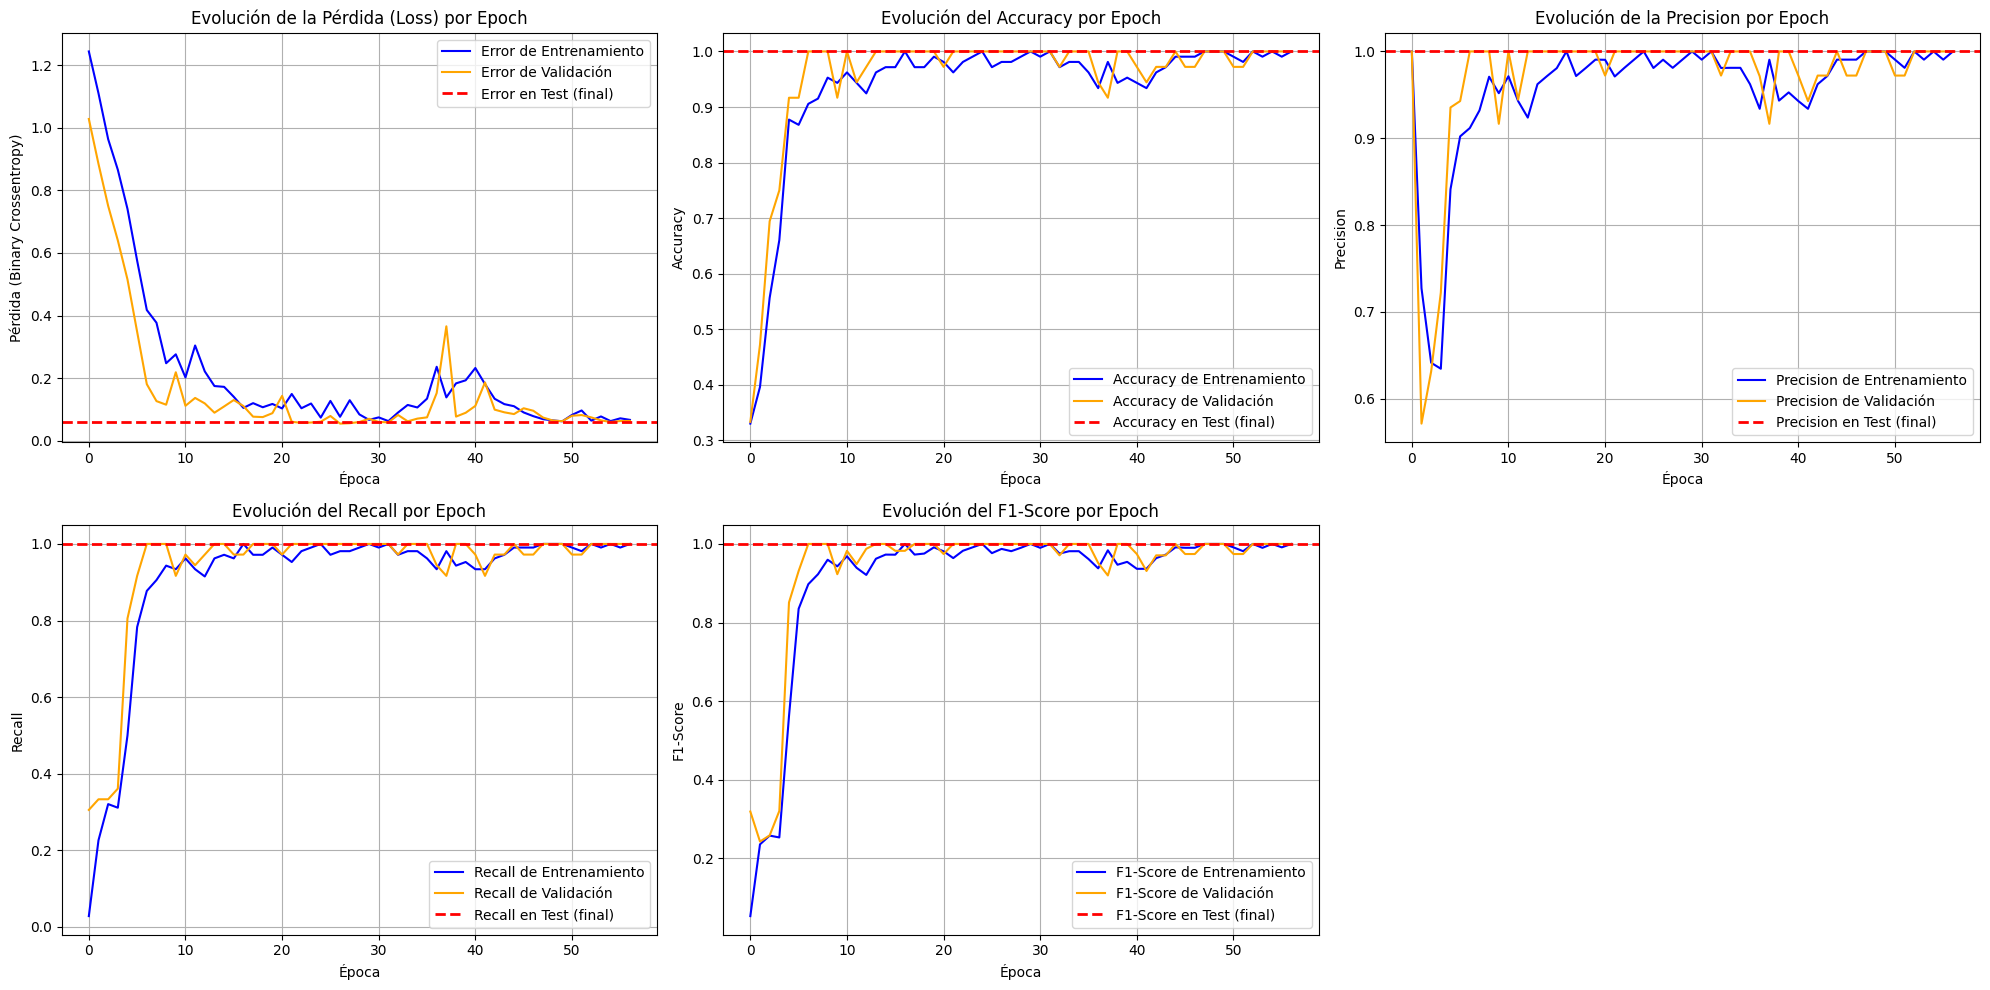

In [10]:
# MODELO 9: OPTIMIZADO PARA PRECISION (Evitar falsas clasificaciones)
X = df.drop(columns=['class'])
y = tf.keras.utils.to_categorical(df['class'] - 1)

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
X_temp, X_test_opt_prec, y_temp, y_test_opt_prec = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)
X_train_opt_prec, X_val_opt_prec, y_train_opt_prec, y_val_opt_prec = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp)

print(f"Train: {len(X_train_opt_prec)} | Validation: {len(X_val_opt_prec)} | Test: {len(X_test_opt_prec)}")

print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_opt_prec = MinMaxScaler()
X_train_opt_prec_scaled = scaler_opt_prec.fit_transform(X_train_opt_prec)
X_val_opt_prec_scaled = scaler_opt_prec.transform(X_val_opt_prec)
X_test_opt_prec_scaled = scaler_opt_prec.transform(X_test_opt_prec)

# Pesos para priorizar PRECISION: distribución diferente para enfatizar precisión
# Para multiclase con 3 categorías, ajustamos equilibradamente
precision_weights = {0: 1.2, 1: 1.0, 2: 1.2}

model_opt_prec = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, input_shape=[X_train_opt_prec_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.Dense(units=8, activation='relu'),
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_opt_prec.compile(
    optimizer=tf.keras.optimizers.Adam(0.01), 
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)]
)

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print(f'Entrenando Modelo 9 (Optimizado para Precision - class_weight={precision_weights})...')
history_opt_prec = model_opt_prec.fit(
    X_train_opt_prec_scaled, y_train_opt_prec, 
    epochs=200, 
    validation_data=(X_val_opt_prec_scaled, y_val_opt_prec),
    class_weight=precision_weights,
    callbacks=[early_stop],
    verbose=0
)

results_opt_prec = model_opt_prec.evaluate(X_test_opt_prec_scaled, y_test_opt_prec, verbose=0)
loss_opt_prec, accuracy_opt_prec, precision_opt_prec, recall_opt_prec, f1_opt_prec = results_opt_prec
print(f'Métricas Modelo 9 en Test:')
print(f'  Pérdida: {loss_opt_prec:.4f}')
print(f'  Accuracy: {accuracy_opt_prec:.4f}')
print(f'  Precision: {precision_opt_prec:.4f}')
print(f'  Recall: {recall_opt_prec:.4f}')
print(f'  F1-Score: {f1_opt_prec:.4f}')
print(f'  Épocas entrenadas: {len(history_opt_prec.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_opt_prec.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_opt_prec.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_opt_prec, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_opt_prec.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_opt_prec.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_opt_prec, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_opt_prec.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_opt_prec.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_opt_prec, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_opt_prec.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_opt_prec.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_opt_prec, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_opt_prec.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_opt_prec.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_opt_prec, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Splitting data: 60% train, 20% validation, 20% test...
NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases
Train: 106 | Validation: 36 | Test: 36
Scaling features using Min-Max Scaling (fitted only on training data)...
Entrenando Modelo 10 (Optimizado para F1-Score - class_weight balanceado: {0: np.float64(1.0095238095238095), 1: np.float64(0.8217054263565892), 2: np.float64(1.2619047619047619)})...


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Métricas Modelo 10 en Test:
  Pérdida: 0.0372
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Épocas entrenadas: 108


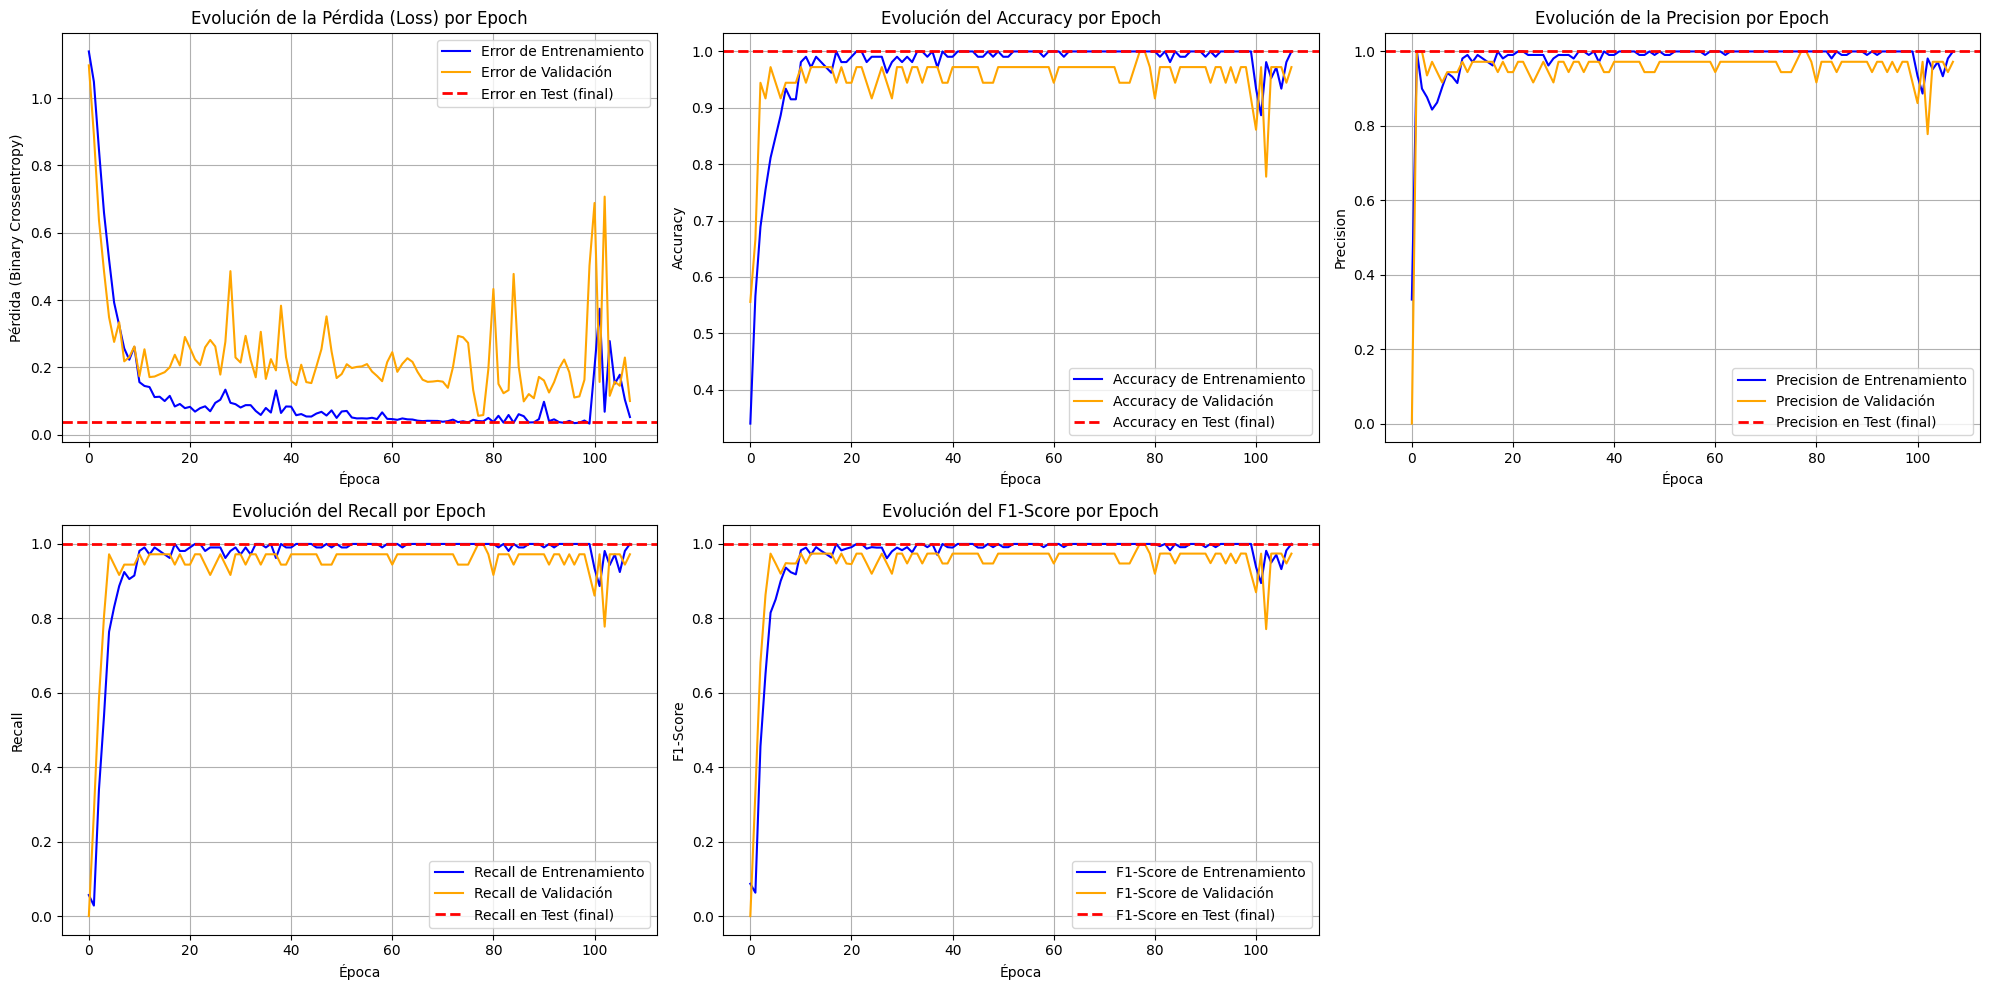

In [11]:
# MODELO 10: OPTIMIZADO PARA F1-SCORE (Balance entre Precision y Recall)
from sklearn.utils.class_weight import compute_class_weight

X = df.drop(columns=['class'])
y_int = df['class'] - 1  # Etiquetas enteras para stratify y class_weight

print("\nSplitting data: 60% train, 20% validation, 20% test...")
print("NOTA: shuffle=True (por defecto) y stratify activado para mantener proporción de clases")
X_temp, X_test_opt_f1, y_temp, y_test_opt_f1 = train_test_split(
    X, y_int, test_size=0.20, random_state=42, shuffle=True, stratify=y_int
)

X_train_opt_f1, X_val_opt_f1, y_train_opt_f1, y_val_opt_f1 = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True, stratify=y_temp
)

print(f"Train: {len(X_train_opt_f1)} | Validation: {len(X_val_opt_f1)} | Test: {len(X_test_opt_f1)}")

# One-hot encoding DESPUÉS del split
y_train_opt_f1 = tf.keras.utils.to_categorical(y_train_opt_f1, num_classes=3)
y_val_opt_f1   = tf.keras.utils.to_categorical(y_val_opt_f1, num_classes=3)
y_test_opt_f1  = tf.keras.utils.to_categorical(y_test_opt_f1, num_classes=3)

print("Scaling features using Min-Max Scaling (fitted only on training data)...")
scaler_opt_f1 = MinMaxScaler()
X_train_opt_f1_scaled = scaler_opt_f1.fit_transform(X_train_opt_f1)
X_val_opt_f1_scaled   = scaler_opt_f1.transform(X_val_opt_f1)
X_test_opt_f1_scaled  = scaler_opt_f1.transform(X_test_opt_f1)

# Cálculo correcto de class_weight
y_train_labels = np.argmax(y_train_opt_f1, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
f1_weights = {0: class_weight_dict[0], 1: class_weight_dict[1], 2: class_weight_dict[2]}

model_opt_f1 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, input_shape=[X_train_opt_f1_scaled.shape[1]], activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=32, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=16, activation='relu'),
    tf.keras.layers.Dense(units=8, activation='relu'),
    tf.keras.layers.Dense(units=3, activation='softmax')
])

model_opt_f1.compile(
    optimizer=tf.keras.optimizers.Adam(0.01), 
    loss='categorical_crossentropy',
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.F1Score(average='macro', name='f1_score', threshold=0.5)]
)

# Early stopping para evitar overfitting
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

print(f'Entrenando Modelo 10 (Optimizado para F1-Score - class_weight balanceado: {f1_weights})...')
history_opt_f1 = model_opt_f1.fit(
    X_train_opt_f1_scaled, y_train_opt_f1, 
    epochs=200, 
    validation_data=(X_val_opt_f1_scaled, y_val_opt_f1),
    class_weight=f1_weights,
    callbacks=[early_stop],
    verbose=0
)

results_opt_f1 = model_opt_f1.evaluate(X_test_opt_f1_scaled, y_test_opt_f1, verbose=0)
loss_opt_f1, accuracy_opt_f1, precision_opt_f1, recall_opt_f1, f1_opt_f1 = results_opt_f1
print(f'Métricas Modelo 10 en Test:')
print(f'  Pérdida: {loss_opt_f1:.4f}')
print(f'  Accuracy: {accuracy_opt_f1:.4f}')
print(f'  Precision: {precision_opt_f1:.4f}')
print(f'  Recall: {recall_opt_f1:.4f}')
print(f'  F1-Score: {f1_opt_f1:.4f}')
print(f'  Épocas entrenadas: {len(history_opt_f1.history["loss"])}')

# Plot del proceso de los epochs
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.plot(history_opt_f1.history['loss'], color='blue', label='Error de Entrenamiento')
plt.plot(history_opt_f1.history['val_loss'], color='orange', label='Error de Validación')
plt.axhline(y=loss_opt_f1, color='red', linestyle='--', linewidth=2, label='Error en Test (final)')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Binary Crossentropy)')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(history_opt_f1.history['accuracy'], color='blue', label='Accuracy de Entrenamiento')
plt.plot(history_opt_f1.history['val_accuracy'], color='orange', label='Accuracy de Validación')
plt.axhline(y=accuracy_opt_f1, color='red', linestyle='--', linewidth=2, label='Accuracy en Test (final)')
plt.title('Evolución del Accuracy por Epoch')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(history_opt_f1.history['precision'], color='blue', label='Precision de Entrenamiento')
plt.plot(history_opt_f1.history['val_precision'], color='orange', label='Precision de Validación')
plt.axhline(y=precision_opt_f1, color='red', linestyle='--', linewidth=2, label='Precision en Test (final)')
plt.title('Evolución de la Precision por Epoch')
plt.xlabel('Época')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(history_opt_f1.history['recall'], color='blue', label='Recall de Entrenamiento')
plt.plot(history_opt_f1.history['val_recall'], color='orange', label='Recall de Validación')
plt.axhline(y=recall_opt_f1, color='red', linestyle='--', linewidth=2, label='Recall en Test (final)')
plt.title('Evolución del Recall por Epoch')
plt.xlabel('Época')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(history_opt_f1.history['f1_score'], color='blue', label='F1-Score de Entrenamiento')
plt.plot(history_opt_f1.history['val_f1_score'], color='orange', label='F1-Score de Validación')
plt.axhline(y=f1_opt_f1, color='red', linestyle='--', linewidth=2, label='F1-Score en Test (final)')
plt.title('Evolución del F1-Score por Epoch')
plt.xlabel('Época')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000222AB0A5440> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━

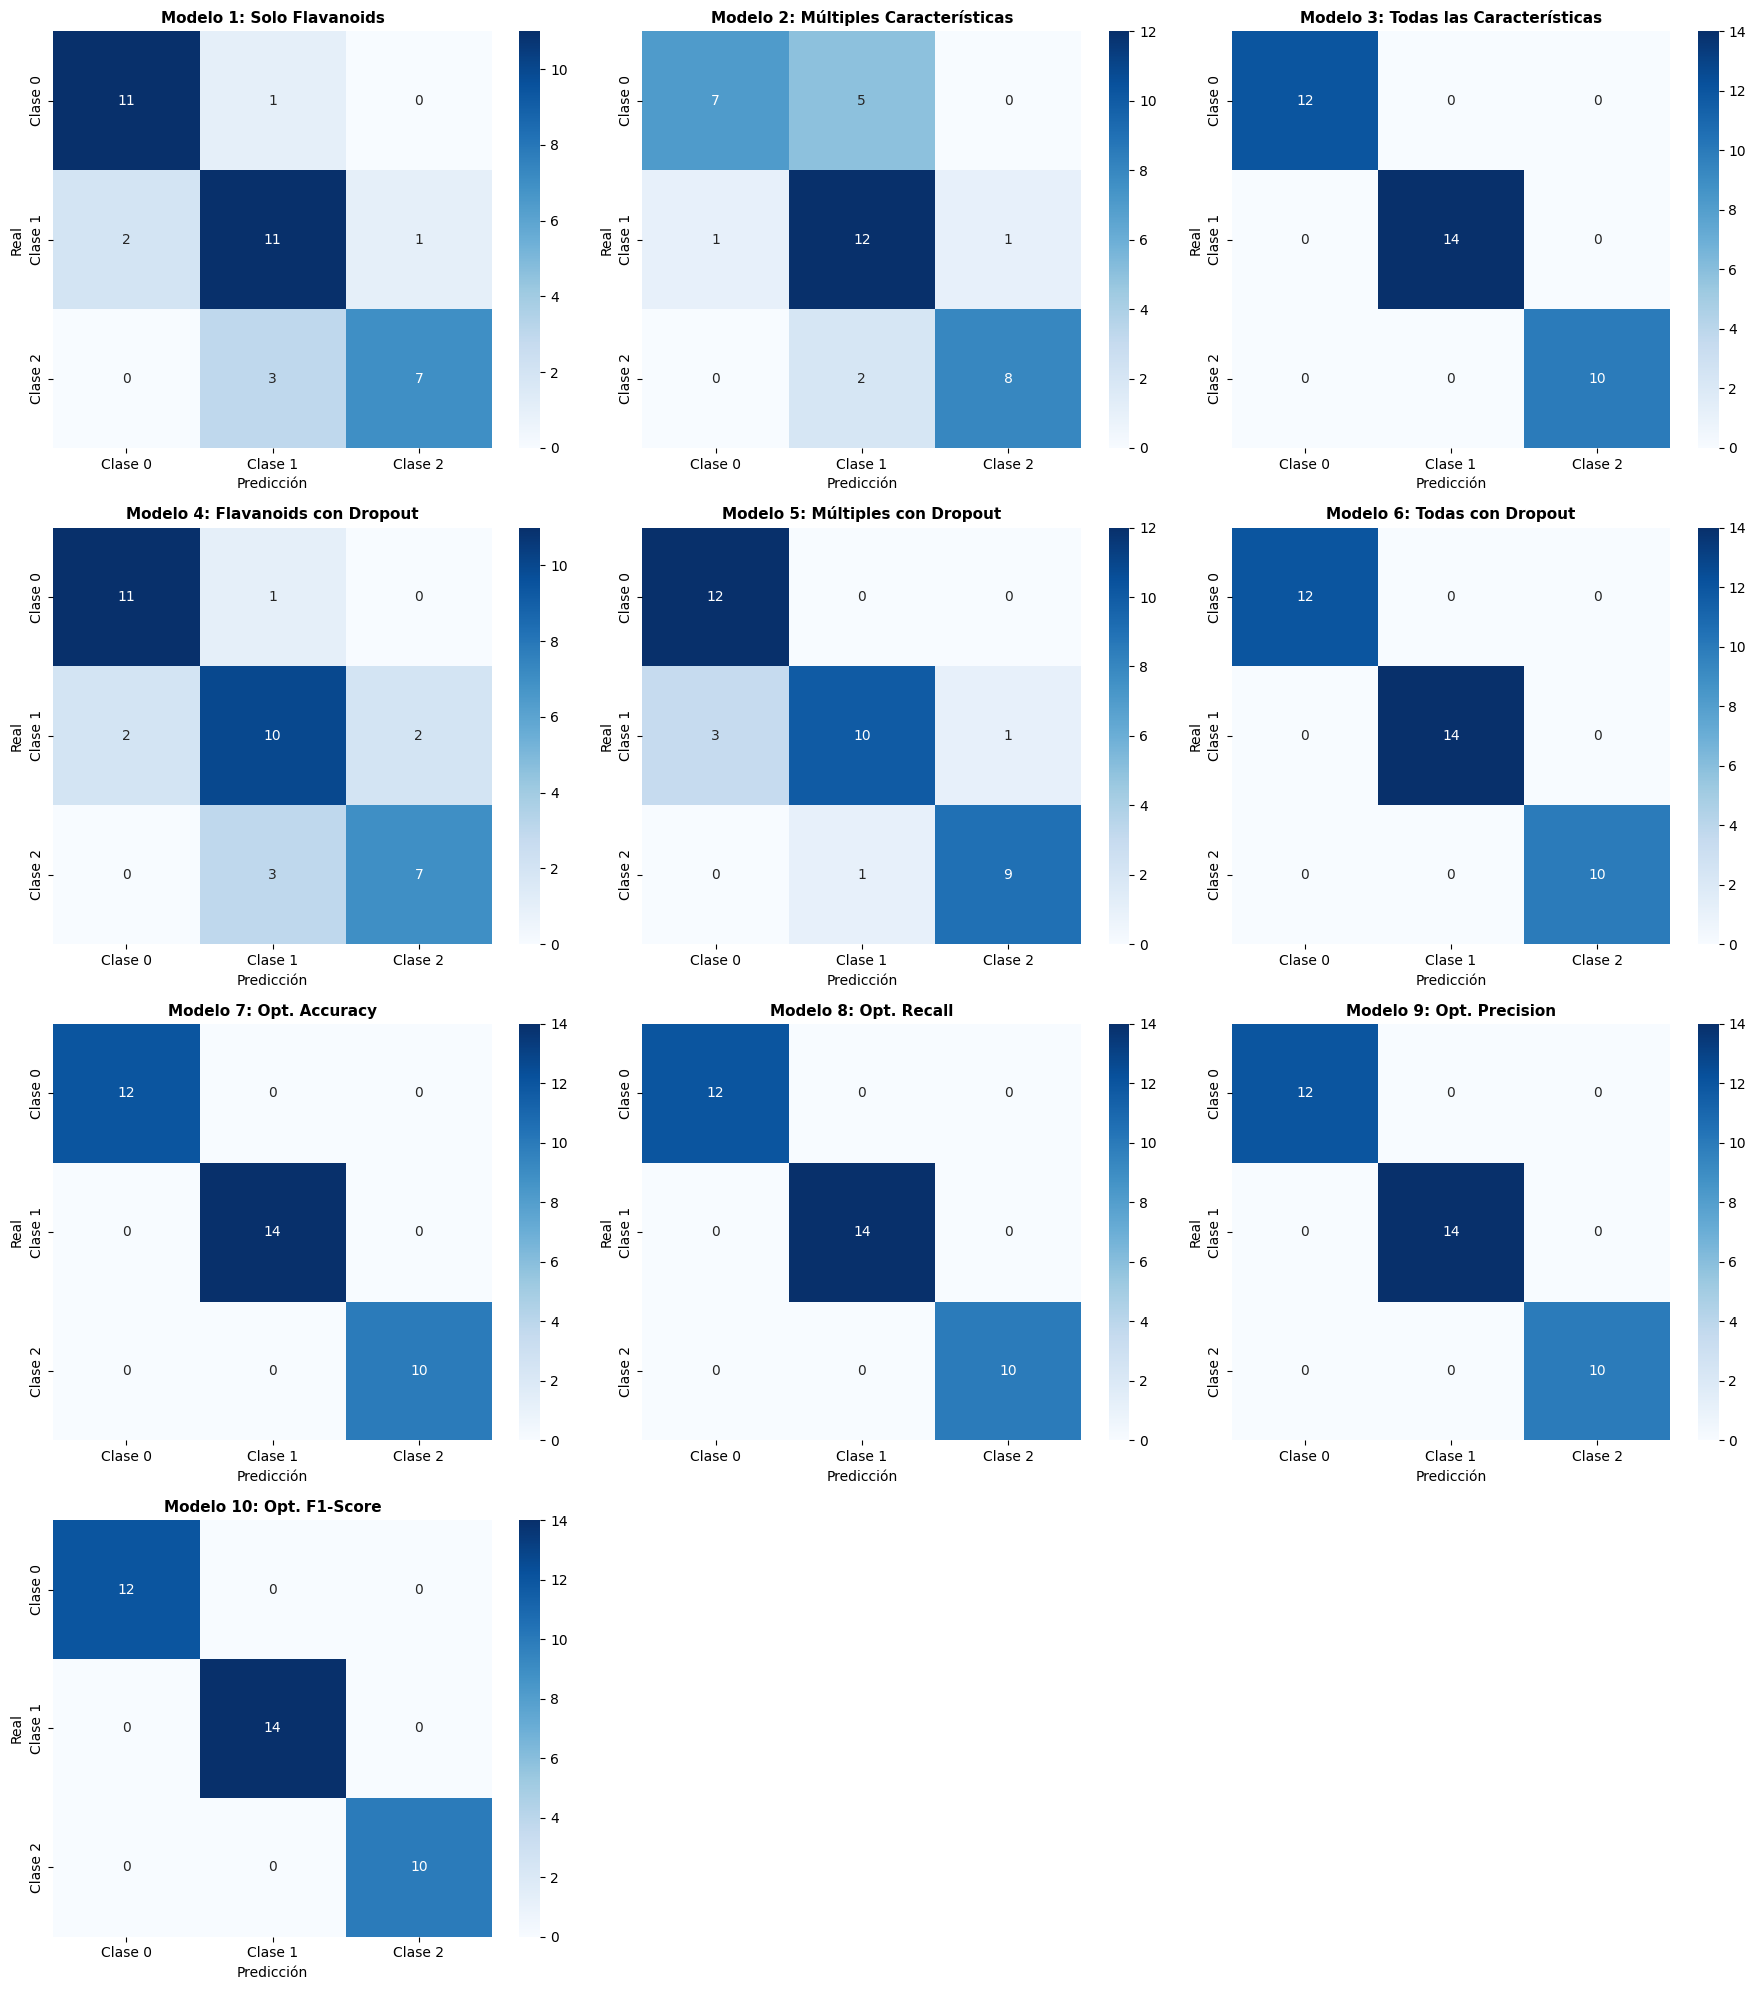


Comparativa de predicciones en conjunto de TEST (primeros 10 registros):
   Real  M1_Simple  M2_Multi  M3_Multi_All  M4_Drop  M5_Drop_Multi  \
0     2          1         2             2        1              2   
1     0          0         0             0        0              0   
2     2          2         2             2        2              2   
3     1          0         1             1        0              0   
4     1          1         1             1        1              1   
5     1          1         1             1        1              1   
6     2          2         2             2        2              2   
7     1          1         1             1        2              1   
8     0          0         0             0        0              0   
9     0          1         1             0        1              0   

   M6_Drop_All  M7_Opt_Acc  M8_Opt_Rec  M9_Opt_Prec  M10_Opt_F1  
0            2           2           2            2           0  
1            0         

In [12]:
# Predicciones en el conjunto de TEST (probabilidades)
pred_1_prob = model_1.predict(X_test_1_scaled)
pred_M_prob = model_M.predict(X_test_M_scaled)
pred_M_all_prob = model_M_all.predict(X_test_M_all_scaled)
pred_1_a_prob = model_1_a.predict(X_test_1_a_scaled)
pred_M_a_prob = model_M_a.predict(X_test_M_a_scaled)
pred_M_a_all_prob = model_M_a_all.predict(X_test_M_a_all_scaled)
pred_opt_acc_prob = model_opt_acc.predict(X_test_opt_acc_scaled)
pred_opt_rec_prob = model_opt_rec.predict(X_test_opt_rec_scaled)
pred_opt_prec_prob = model_opt_prec.predict(X_test_opt_prec_scaled)
pred_opt_f1_prob = model_opt_f1.predict(X_test_opt_f1_scaled)

# Convertir probabilidades a clases (argmax para multiclase)
pred_1 = np.argmax(pred_1_prob, axis=1)
pred_M = np.argmax(pred_M_prob, axis=1)
pred_M_all = np.argmax(pred_M_all_prob, axis=1)
pred_1_a = np.argmax(pred_1_a_prob, axis=1)
pred_M_a = np.argmax(pred_M_a_prob, axis=1)
pred_M_a_all = np.argmax(pred_M_a_all_prob, axis=1)
pred_opt_acc = np.argmax(pred_opt_acc_prob, axis=1)
pred_opt_rec = np.argmax(pred_opt_rec_prob, axis=1)
pred_opt_prec = np.argmax(pred_opt_prec_prob, axis=1)
pred_opt_f1 = np.argmax(pred_opt_f1_prob, axis=1)

# Convertir one-hot encoding a clases para las etiquetas reales
y_test_1_classes = np.argmax(y_test_1, axis=1)
y_test_M_classes = np.argmax(y_test_M, axis=1)
y_test_M_all_classes = np.argmax(y_test_M_all, axis=1)
y_test_1_a_classes = np.argmax(y_test_1_a, axis=1)
y_test_M_a_classes = np.argmax(y_test_M_a, axis=1)
y_test_M_a_all_classes = np.argmax(y_test_M_a_all, axis=1)
y_test_opt_acc_classes = np.argmax(y_test_opt_acc, axis=1)
y_test_opt_rec_classes = np.argmax(y_test_opt_rec, axis=1)
y_test_opt_prec_classes = np.argmax(y_test_opt_prec, axis=1)
y_test_opt_f1_classes = np.argmax(y_test_opt_f1, axis=1)

# Matrices de confusión para TODOS los modelos
fig, axes = plt.subplots(4, 3, figsize=(18, 20))

modelos = [
    ('Modelo 1: Solo Flavanoids', pred_1, y_test_1_classes),
    ('Modelo 2: Múltiples Características', pred_M, y_test_M_classes),
    ('Modelo 3: Todas las Características', pred_M_all, y_test_M_all_classes),
    ('Modelo 4: Flavanoids con Dropout', pred_1_a, y_test_1_a_classes),
    ('Modelo 5: Múltiples con Dropout', pred_M_a, y_test_M_a_classes),
    ('Modelo 6: Todas con Dropout', pred_M_a_all, y_test_M_a_all_classes),
    ('Modelo 7: Opt. Accuracy', pred_opt_acc, y_test_opt_acc_classes),
    ('Modelo 8: Opt. Recall', pred_opt_rec, y_test_opt_rec_classes),
    ('Modelo 9: Opt. Precision', pred_opt_prec, y_test_opt_prec_classes),
    ('Modelo 10: Opt. F1-Score', pred_opt_f1, y_test_opt_f1_classes)
]

for idx, (titulo, pred, y_real) in enumerate(modelos):
    row = idx // 3
    col = idx % 3
    cm = confusion_matrix(y_real, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col], 
                xticklabels=['Clase 0', 'Clase 1', 'Clase 2'], 
                yticklabels=['Clase 0', 'Clase 1', 'Clase 2'])
    axes[row, col].set_title(titulo, fontsize=11, fontweight='bold')
    axes[row, col].set_ylabel('Real')
    axes[row, col].set_xlabel('Predicción')

# Eliminar subplots vacíos
for idx in range(len(modelos), 12):
    row = idx // 3
    col = idx % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

# Tabla comparativa de los primeros 10 registros del conjunto de TEST
comparativa = pd.DataFrame({
    'Real': y_test_1_classes[:10],
    'M1_Simple': pred_1[:10],
    'M2_Multi': pred_M[:10],
    'M3_Multi_All': pred_M_all[:10],
    'M4_Drop': pred_1_a[:10],
    'M5_Drop_Multi': pred_M_a[:10],
    'M6_Drop_All': pred_M_a_all[:10],
    'M7_Opt_Acc': pred_opt_acc[:10],
    'M8_Opt_Rec': pred_opt_rec[:10],
    'M9_Opt_Prec': pred_opt_prec[:10],
    'M10_Opt_F1': pred_opt_f1[:10]
})

print('\nComparativa de predicciones en conjunto de TEST (primeros 10 registros):')
print(comparativa)


Resumen de Métricas de Clasificación (TODOS LOS MODELOS):
                   Accuracy  Precision    Recall  F1-Score
M6: Drop All       1.000000   1.000000  1.000000  1.000000
M3: Multi All      1.000000   1.000000  1.000000  1.000000
M9: Opt Precision  1.000000   1.000000  1.000000  1.000000
M10: Opt F1        1.000000   1.000000  1.000000  1.000000
M8: Opt Recall     1.000000   1.000000  1.000000  1.000000
M7: Opt Acc        1.000000   1.000000  1.000000  1.000000
M5: Drop Multi     0.861111   0.869697  0.871429  0.862963
M1: Simple         0.805556   0.818162  0.800794  0.805466
M4: Drop           0.777778   0.779406  0.776984  0.777043
M2: Multi          0.750000   0.798489  0.746825  0.756459

El modelo con mejor F1-Score es: M6: Drop All
F1-Score: 1.0000
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000

MEJORES MODELOS POR MÉTRICA:
Accuracy    : M6: Drop All         = 1.0000
Precision   : M6: Drop All         = 1.0000
Recall      : M6: Drop All         = 1.0000
F1-Score    : M6

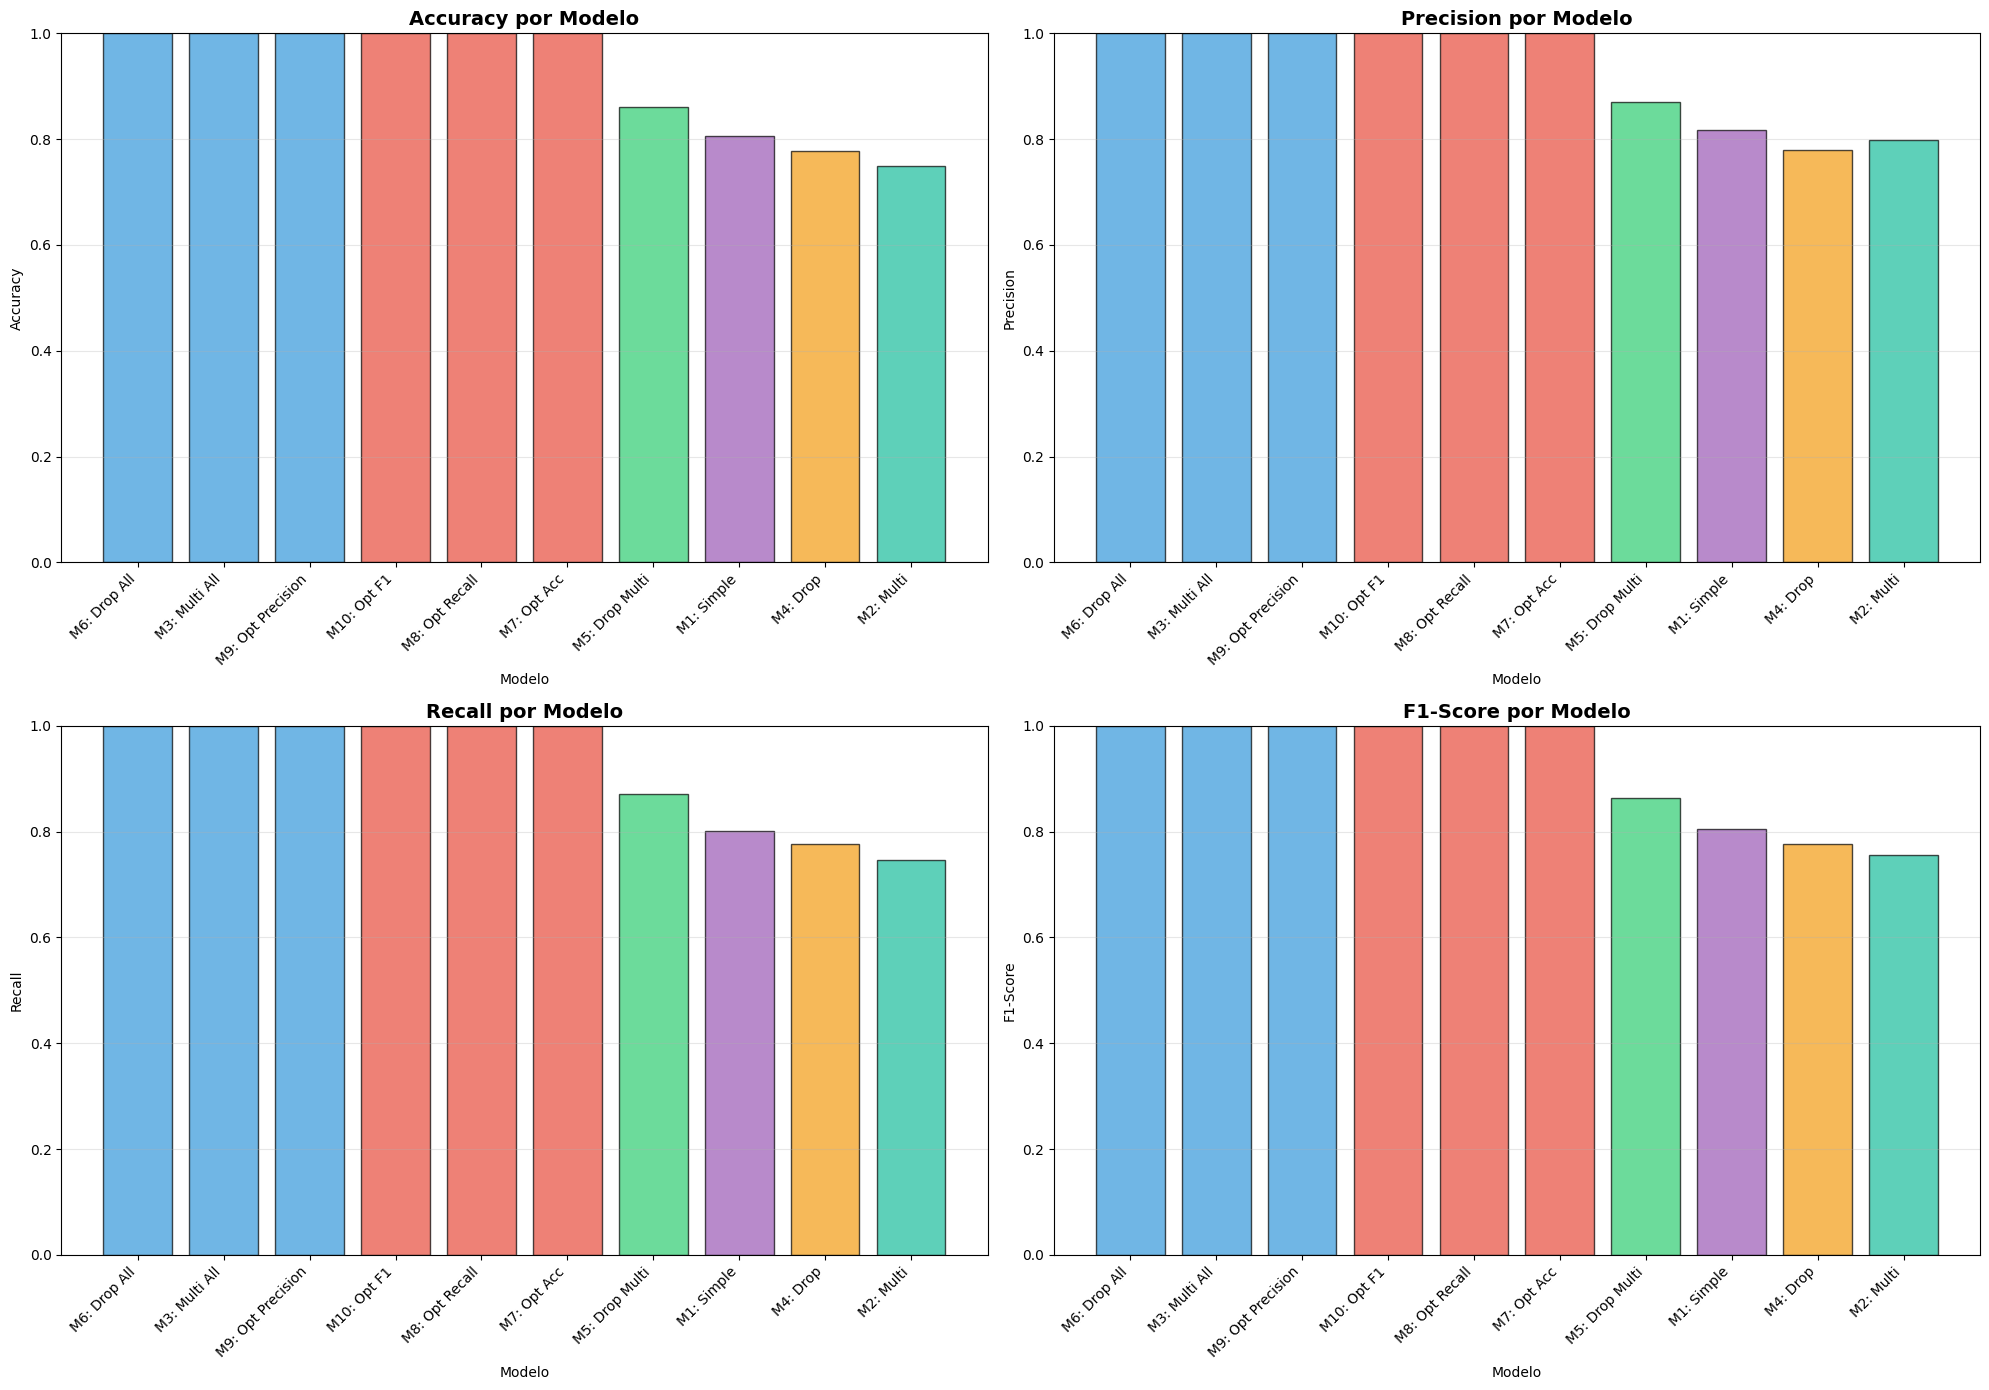


REPORTES DE CLASIFICACIÓN DETALLADOS

M1: Simple:
              precision    recall  f1-score   support

     Clase 0       0.85      0.92      0.88        12
     Clase 1       0.73      0.79      0.76        14
     Clase 2       0.88      0.70      0.78        10

    accuracy                           0.81        36
   macro avg       0.82      0.80      0.81        36
weighted avg       0.81      0.81      0.80        36


M2: Multi:
              precision    recall  f1-score   support

     Clase 0       0.88      0.58      0.70        12
     Clase 1       0.63      0.86      0.73        14
     Clase 2       0.89      0.80      0.84        10

    accuracy                           0.75        36
   macro avg       0.80      0.75      0.76        36
weighted avg       0.78      0.75      0.75        36


M3: Multi All:
              precision    recall  f1-score   support

     Clase 0       1.00      1.00      1.00        12
     Clase 1       1.00      1.00      1.00       

In [13]:
# Cada modelo debe compararse con su propio conjunto de test real
modelos_data = {
    'M1: Simple': (y_test_1_classes, pred_1),
    'M2: Multi': (y_test_M_classes, pred_M),
    'M3: Multi All': (y_test_M_all_classes, pred_M_all),
    'M4: Drop': (y_test_1_a_classes, pred_1_a),
    'M5: Drop Multi': (y_test_M_a_classes, pred_M_a),
    'M6: Drop All': (y_test_M_a_all_classes, pred_M_a_all),
    'M7: Opt Acc': (y_test_opt_acc_classes, pred_opt_acc),
    'M8: Opt Recall': (y_test_opt_rec_classes, pred_opt_rec),
    'M9: Opt Precision': (y_test_opt_prec_classes, pred_opt_prec),
    'M10: Opt F1': (y_test_opt_f1_classes, pred_opt_f1)
}

metricas_dict = {}

for nombre, (real, pred) in modelos_data.items():
    metricas_dict[nombre] = {
        'Accuracy': accuracy_score(real, pred),
        'Precision': precision_score(real, pred, average='macro', zero_division=0),
        'Recall': recall_score(real, pred, average='macro', zero_division=0),
        'F1-Score': f1_score(real, pred, average='macro', zero_division=0)
    }

resumen_rendimiento = pd.DataFrame(metricas_dict).T

resumen_rendimiento = resumen_rendimiento.sort_values(by='F1-Score', ascending=False)

print('\nResumen de Métricas de Clasificación (TODOS LOS MODELOS):')
print(resumen_rendimiento)

modelo_mejor_general = resumen_rendimiento.index[0]
print(f'\n{"="*80}')
print(f'El modelo con mejor F1-Score es: {modelo_mejor_general}')
print(f'{"="*80}')
print(f'F1-Score: {resumen_rendimiento.loc[modelo_mejor_general, "F1-Score"]:.4f}')
print(f'Accuracy: {resumen_rendimiento.loc[modelo_mejor_general, "Accuracy"]:.4f}')
print(f'Precision: {resumen_rendimiento.loc[modelo_mejor_general, "Precision"]:.4f}')
print(f'Recall: {resumen_rendimiento.loc[modelo_mejor_general, "Recall"]:.4f}')

# Encontrar el mejor modelo para cada métrica
print(f'\n{"="*80}')
print('MEJORES MODELOS POR MÉTRICA:')
print(f'{"="*80}')
for metrica in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    mejor_modelo = resumen_rendimiento[metrica].idxmax()
    mejor_valor = resumen_rendimiento.loc[mejor_modelo, metrica]
    print(f'{metrica:12s}: {mejor_modelo:20s} = {mejor_valor:.4f}')

# Gráficos de barras del resumen
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

colores_modelos = ['#3498db', '#3498db', '#3498db', '#e74c3c', '#e74c3c', '#e74c3c', 
                   '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

# Gráfico 1: Accuracy
axes[0, 0].bar(range(len(resumen_rendimiento)), resumen_rendimiento['Accuracy'], 
               color=colores_modelos, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Accuracy por Modelo', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Modelo')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_xticks(range(len(resumen_rendimiento)))
axes[0, 0].set_xticklabels(resumen_rendimiento.index, rotation=45, ha='right')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# Gráfico 2: Precision
axes[0, 1].bar(range(len(resumen_rendimiento)), resumen_rendimiento['Precision'], 
               color=colores_modelos, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Precision por Modelo', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Modelo')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_xticks(range(len(resumen_rendimiento)))
axes[0, 1].set_xticklabels(resumen_rendimiento.index, rotation=45, ha='right')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# Gráfico 3: Recall
axes[1, 0].bar(range(len(resumen_rendimiento)), resumen_rendimiento['Recall'], 
               color=colores_modelos, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Recall por Modelo', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Modelo')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_xticks(range(len(resumen_rendimiento)))
axes[1, 0].set_xticklabels(resumen_rendimiento.index, rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Gráfico 4: F1-Score
axes[1, 1].bar(range(len(resumen_rendimiento)), resumen_rendimiento['F1-Score'], 
               color=colores_modelos, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('F1-Score por Modelo', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Modelo')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_xticks(range(len(resumen_rendimiento)))
axes[1, 1].set_xticklabels(resumen_rendimiento.index, rotation=45, ha='right')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Reportes de clasificación detallados
print("\n" + "="*80)
print("REPORTES DE CLASIFICACIÓN DETALLADOS")
print("="*80)

for nombre, (real, pred) in modelos_data.items():
    print(f"\n{nombre}:")
    print(classification_report(real, pred, target_names=['Clase 0', 'Clase 1', 'Clase 2']))